# Value and Momentum Everywhere
## Indian Equity Markets — Asness, Moskowitz & Pedersen (2013)

---

### Paper Summary

Asness, Moskowitz & Pedersen (*Journal of Finance*, 2013) document consistent **value** and **momentum** return premia across eight diverse asset classes and uncover:

1. **Both premia are positive and significant** in every market examined
2. **Value and momentum are negatively correlated** — within and across asset classes (central finding)
3. **50/50 combination** achieves higher Sharpe ratio than either strategy alone
4. A simple **3-factor model** (Global MKT + VAL + MOM) prices returns globally

### Signal Definitions

| Signal | Formula | Intuition |
|--------|---------|-----------|
| **Value (V)** | $V_t = -R_{t-60,t-1}$ (5-yr reversal for indices) | Long-run loser = cheap = value |
| **Value (V₂)** | $(P_{52wk\_high} - P_t)\,/\,P_{52wk\_high}$ (for stocks) | Distance from peak = value proxy |
| **Momentum (MOM)** | $MOM_t = R_{t-13,t-2}$ (12-1 return) | Past winner = momentum |
| **Combo** | $C_t = 0.5\,z(V_t) + 0.5\,z(MOM_t)$ | Equal-weight z-scored signals |

### Factor Construction (Eq. 1–2, paper)
Signal-weighted zero-cost portfolio: $w_{it} = c_t\!\left[\text{rank}(S_{it}) - \bar{\text{rank}}_t\right]$, scaled so long = $1, short = -1$.

### Data
- **Indices**: NIFTY 50 · BANK NIFTY · SENSEX · NIFTY MIDCAP 100
- **Stock universe**: NIFTY 50 + Midcap + Smallcap stocks (~447 stocks; filtered to ≥60 months of history)
- **Period**: 2005–2025 (monthly)
- **Risk-free rate**: 6% p.a. (India T-Bill proxy)

In [1]:
import pandas as pd  # import labelled DataFrames / Series aliased as pd
import numpy as np  # import vectorised numerical arrays aliased as np
import matplotlib.pyplot as plt  # import figure / axes plotting aliased as plt
import matplotlib.ticker as mticker  # import axis tick formatters aliased as mticker
import matplotlib.gridspec as gridspec  # import subplot grid layout aliased as gridspec
import matplotlib.patches as mpatches  # import shape patches for plots aliased as mpatches
import seaborn as sns  # import statistical heatmaps and plots aliased as sns
from scipy import stats  # pull stats from scientific computing suite
import statsmodels.api as sm  # import OLS regression with diagnostics aliased as sm
import os, warnings
warnings.filterwarnings('ignore')  # silence all deprecation/convergence warnings

# ── Dark theme ────────────────────────────────────────────────────────────────
BG, PANEL, BORDER = '#0D1117', '#161B22', '#30363D'
GRID, TEXT, MUTED  = '#21262D', '#E6EDF3', '#8B949E'

plt.rcParams.update({  # update global matplotlib style settings
    'figure.facecolor': BG,   'axes.facecolor': PANEL,
    'axes.edgecolor':  BORDER,'axes.labelcolor': TEXT,
    'xtick.color':     MUTED, 'ytick.color':    MUTED,
    'text.color':      TEXT,  'grid.color':     GRID,
    'grid.alpha':      1.0,   'grid.linewidth': 0.6,
    'legend.facecolor':PANEL, 'legend.edgecolor':BORDER,
    'figure.titlesize':15,    'axes.titlesize':  12,
    'axes.labelsize':  10,    'font.size':       10,
    'lines.linewidth': 1.8,
})

# ── Color palette ─────────────────────────────────────────────────────────────
C = {
    'val'      : '#FFD700',   # Gold     — Value
    'mom'      : '#00D4FF',   # Cyan     — Momentum
    'combo'    : '#C084FC',   # Violet   — Combo
    'nifty'    : '#00FF7F',   # Green    — NIFTY 50
    'banknifty': '#FF69B4',   # Pink     — BANK NIFTY
    'sensex'   : '#FF8C00',   # Orange   — SENSEX
    'midcap'   : '#F97316',   # Amber    — MIDCAP 100
    'pos'      : '#2EA043',   # Green
    'neg'      : '#F85149',   # Red
    'neutral'  : '#8B949E',   # Gray
}

print('✓ Imports | Dark theme configured')  # display output / progress message

✓ Imports | Dark theme configured


In [2]:
DATA_DIR   = '../dataset'  # path to CSV price data directory
RF_ANNUAL  = 0.06  # risk-free rate constant (India T-Bill proxy)
RF_MONTHLY = (1 + RF_ANNUAL) ** (1/12) - 1  # risk-free rate constant (India T-Bill proxy)
START, END = '2005-01-01', '2025-12-31'

def load_csv(ticker):  # define function load_csv()
    df = pd.read_csv(os.path.join(DATA_DIR, f'{ticker}.csv'))  # path to CSV price data directory
    df['date'] = pd.to_datetime(df['date'], utc=True).dt.tz_localize(None)
    df.set_index('date', inplace=True)
    return df.sort_index()  # return computed result to caller

# ── Load indices ──────────────────────────────────────────────────────────────
nifty     = load_csv('NIFTY')
banknifty = load_csv('BANKNIFTY')
sensex    = load_csv('SENSEX')
midcap    = load_csv('NIFTY_MIDCAP_100')

# ── Load stocks — NIFTY 50 + Midcap + Smallcap (exclude index files) ─────────
SKIP = {'NIFTY', 'BANKNIFTY', 'SENSEX', 'NIFTY_MIDCAP_100'}
tickers = sorted([f.replace('.csv','') for f in os.listdir(DATA_DIR)  # path to CSV price data directory
                  if f.endswith('.csv') and f.replace('.csv','') not in SKIP])  # conditional branch
stocks = {}
for t in tickers:  # iterate over each element
    try:  # attempt potentially-failing block
        stocks[t] = load_csv(t)
    except Exception:  # handle any exception silently
        pass  # placeholder — nothing to do here

print(f'✓ Loaded {len(stocks)} stocks (NIFTY 50 + Midcap + Smallcap)')  # display output / progress message
print(f'  Indices: NIFTY 50, BANK NIFTY, SENSEX, MIDCAP 100')  # display output / progress message
print(f'  NIFTY range : {nifty.index[0].date()} → {nifty.index[-1].date()}')  # display output / progress message

✓ Loaded 447 stocks (NIFTY 50 + Midcap + Smallcap)
  Indices: NIFTY 50, BANK NIFTY, SENSEX, MIDCAP 100
  NIFTY range : 2000-01-02 → 2026-04-29


In [3]:
def monthly_close(df, col='close'):  # define function monthly_close()
    return df[col].resample('ME').last().loc[START:END]  # return computed result to caller

def monthly_ret(df, col='close'):  # define function monthly_ret()
    return monthly_close(df, col).pct_change().dropna()  # return computed result to caller

# ── Index monthly close prices (needed for signals) ───────────────────────────
nifty_c     = monthly_close(nifty)
banknifty_c = monthly_close(banknifty)
sensex_c    = monthly_close(sensex)
midcap_c    = monthly_close(midcap)

# ── Index monthly returns ─────────────────────────────────────────────────────
nifty_m, banknifty_m = monthly_ret(nifty), monthly_ret(banknifty)
sensex_m, midcap_m   = monthly_ret(sensex), monthly_ret(midcap)

# ── Stock monthly close prices + returns ──────────────────────────────────────
stock_close = pd.DataFrame({t: monthly_close(df) for t, df in stocks.items()})
stock_ret   = stock_close.pct_change().dropna(how='all')
# Keep stocks with at least 60 monthly observations (5 years of history)
stock_ret   = stock_ret.loc[:, stock_ret.count() >= 60]

print(f'✓ Stock return matrix: {stock_ret.shape[0]} months × {stock_ret.shape[1]} stocks')  # display output / progress message
print(f'  (Stocks with ≥60 monthly obs from {START[:4]}–{END[:4]}; NIFTY 50 + Midcap + Smallcap)')  # display output / progress message
print(f'  Analysis period: {stock_ret.index[0].date()} → {stock_ret.index[-1].date()}')  # display output / progress message
print(f'  Risk-free rate : {RF_MONTHLY*100:.4f}% / month  ({RF_ANNUAL*100:.1f}% / year)')  # display output / progress message

# ── Index return DataFrame ────────────────────────────────────────────────────
IDX_NAMES  = ['NIFTY 50', 'BANK NIFTY', 'SENSEX', 'NIFTY MIDCAP 100']
IDX_COLORS = [C['nifty'], C['banknifty'], C['sensex'], C['midcap']]
idx_ret_df = pd.DataFrame({
    'NIFTY 50'        : nifty_m,
    'BANK NIFTY'      : banknifty_m,
    'SENSEX'          : sensex_m,
    'NIFTY MIDCAP 100': midcap_m,
})

✓ Stock return matrix: 251 months × 345 stocks
  (Stocks with ≥60 monthly obs from 2005–2025; NIFTY 50 + Midcap + Smallcap)
  Analysis period: 2005-02-28 → 2025-12-31
  Risk-free rate : 0.4868% / month  (6.0% / year)


---
## Signal Construction

### Value Signal
- **For equity indices** (4 assets): $V_t = -R_{t-60,t-1}$ — 5-year price reversal
  Long-run losers (beaten down over 5 years) are *cheap / value*. Correlation with B/M: **0.86** (Asness et al.).
- **For individual stocks**: $(P_{52wk\_high} - P_t) / P_{52wk\_high}$ — distance from 52-week peak
  Higher value proxy ↔ more beaten-down relative to recent high.

### Momentum Signal (uniform across all assets)
$MOM_t = P_{t-2} / P_{t-13} - 1$ — 11-month return, skipping most recent month (avoids 1-month reversal)

### Combined Signal (50/50 Combo)
$\text{COMBO}_t = 0.5 \cdot z(V_t) + 0.5 \cdot z(MOM_t)$ where $z$ = monthly cross-sectional z-score

> **Lagging**: All signals use data available *before* the return month. Portfolio formed at end of month $t-1$ earns month $t$ return.

In [4]:
# ── Value Signal 1: 5-year reversal (for indices) ────────────────────────────
def val_5yr(close_series):  # define function val_5yr()
    # V = -(5-year cumulative return). Long-run loser = value.
    return -(close_series / close_series.shift(60) - 1)  # return computed result to caller

idx_val_raw = pd.DataFrame({
    'NIFTY 50'        : val_5yr(nifty_c),
    'BANK NIFTY'      : val_5yr(banknifty_c),
    'SENSEX'          : val_5yr(sensex_c),
    'NIFTY MIDCAP 100': val_5yr(midcap_c),
}).dropna()

# ── Value Signal 2: 52-week high distance (for stocks) ───────────────────────
print('Computing 52-week high value signals for stocks...')  # display output / progress message
val_stock_raw = {}
for t, df in stocks.items():
    if t not in stock_close.columns:  # conditional branch
        continue  # skip to next loop iteration
    roll_h = df['close'].rolling(252, min_periods=120).max()
    v_daily = (roll_h - df['close']) / roll_h.clip(lower=1e-6)
    val_stock_raw[t] = v_daily.resample('ME').last().loc[START:END]  # downsample daily prices to month-end close

val_stock_df = pd.DataFrame(val_stock_raw).reindex(stock_ret.index)

# ── Momentum Signal: 12-1 (for indices + stocks) ──────────────────────────────
def mom_12_1(close_series):  # define function mom_12_1()
    # 12-1 momentum: 11-month return skipping most recent month.
    return close_series.shift(2) / close_series.shift(13) - 1  # return computed result to caller

idx_mom_raw = pd.DataFrame({
    'NIFTY 50'        : mom_12_1(nifty_c),
    'BANK NIFTY'      : mom_12_1(banknifty_c),
    'SENSEX'          : mom_12_1(sensex_c),
    'NIFTY MIDCAP 100': mom_12_1(midcap_c),
}).dropna()

mom_stock_df = pd.DataFrame({t: mom_12_1(stock_close[t])
                              for t in stock_close.columns  # iterate over each element
                              if t in stock_ret.columns}).reindex(stock_ret.index)  # conditional branch

# ── Cross-sectional Z-score ───────────────────────────────────────────────────
def xsec_zscore(df):  # define function xsec_zscore()
    mu = df.mean(axis=1)
    sd = df.std(axis=1).clip(lower=1e-6)
    return df.sub(mu, axis=0).div(sd, axis=0)  # return computed result to caller

val_z_stock   = xsec_zscore(val_stock_df)  # cross-sectional z-score normalisation
mom_z_stock   = xsec_zscore(mom_stock_df)  # cross-sectional z-score normalisation
combo_z_stock = 0.5 * val_z_stock + 0.5 * mom_z_stock

# ── Index z-scores (across 4 indices each month) ─────────────────────────────
idx_val_z   = xsec_zscore(idx_val_raw)  # cross-sectional z-score normalisation
idx_mom_z   = xsec_zscore(idx_mom_raw)  # cross-sectional z-score normalisation
idx_combo_z = 0.5 * idx_val_z + 0.5 * idx_mom_z

print(f'✓ Signals constructed')  # display output / progress message
print(f'  Index value signal (5yr reversal): {len(idx_val_raw)} months  [{idx_val_raw.index[0].date()} → {idx_val_raw.index[-1].date()}]')  # display output / progress message
print(f'  Stock value signal (52wk high):    {val_stock_df.notna().sum().mean():.0f} avg stocks/month')  # display output / progress message
print(f'  Momentum signal (12-1):            {mom_stock_df.notna().sum().mean():.0f} avg stocks/month')  # display output / progress message

Computing 52-week high value signals for stocks...
✓ Signals constructed
  Index value signal (5yr reversal): 192 months  [2010-01-31 → 2025-12-31]
  Stock value signal (52wk high):    160 avg stocks/month
  Momentum signal (12-1):            192 avg stocks/month


In [5]:
# ── Signal summary statistics ─────────────────────────────────────────────────
common_idx = idx_val_raw.index.intersection(idx_mom_raw.index)
val_idx_a  = idx_val_raw.loc[common_idx]
mom_idx_a  = idx_mom_raw.loc[common_idx]

print('═' * 68)  # display output / progress message
print('          VALUE & MOMENTUM SIGNAL STATISTICS — 4 INDICES')  # display output / progress message
print('═' * 68)  # display output / progress message
print(f'  Period: {common_idx[0].date()} → {common_idx[-1].date()}  |  N = {len(common_idx)} months')  # display output / progress message
print()  # display output / progress message
for idx in IDX_NAMES:  # iterate over each element
    v = val_idx_a[idx].dropna()
    m = mom_idx_a[idx].dropna()
    corr_vm = v.corr(m)
    print(f'  {idx:<20}  Val μ={v.mean():+.4f}  σ={v.std():.4f}  '  # display output / progress message
          f'| Mom μ={m.mean():+.4f}  σ={m.std():.4f}  '
          f'| corr(V,M)={corr_vm:+.3f}')

# Cross-asset correlations
print()  # display output / progress message
print('Cross-asset V-MOM correlations:')  # display output / progress message
print(f'  V(NIFTY)  × MOM(NIFTY)   = {val_idx_a["NIFTY 50"].corr(mom_idx_a["NIFTY 50"]):+.3f}')  # display output / progress message
print(f'  V(BNKN)   × MOM(BNKN)    = {val_idx_a["BANK NIFTY"].corr(mom_idx_a["BANK NIFTY"]):+.3f}')  # display output / progress message
print(f'  V(avg)    × MOM(avg)      = {val_idx_a.mean(axis=1).corr(mom_idx_a.mean(axis=1)):+.3f}')  # display output / progress message
print()  # display output / progress message
print('  Paper prediction: V–MOM correlation < 0 (negative correlation)')  # display output / progress message
print('═' * 68)  # display output / progress message

════════════════════════════════════════════════════════════════════
          VALUE & MOMENTUM SIGNAL STATISTICS — 4 INDICES
════════════════════════════════════════════════════════════════════
  Period: 2010-01-31 → 2025-12-31  |  N = 192 months

  NIFTY 50              Val μ=-0.7429  σ=0.3649  | Mom μ=+0.1244  σ=0.1773  | corr(V,M)=-0.449
  BANK NIFTY            Val μ=-0.9610  σ=0.4506  | Mom μ=+0.1603  σ=0.2642  | corr(V,M)=-0.325
  SENSEX                Val μ=-0.7419  σ=0.3721  | Mom μ=+0.1236  σ=0.1762  | corr(V,M)=-0.494
  NIFTY MIDCAP 100      Val μ=-1.0307  σ=0.6986  | Mom μ=+0.1838  σ=0.2933  | corr(V,M)=-0.287

Cross-asset V-MOM correlations:
  V(NIFTY)  × MOM(NIFTY)   = -0.449
  V(BNKN)   × MOM(BNKN)    = -0.325
  V(avg)    × MOM(avg)      = -0.374

  Paper prediction: V–MOM correlation < 0 (negative correlation)
════════════════════════════════════════════════════════════════════


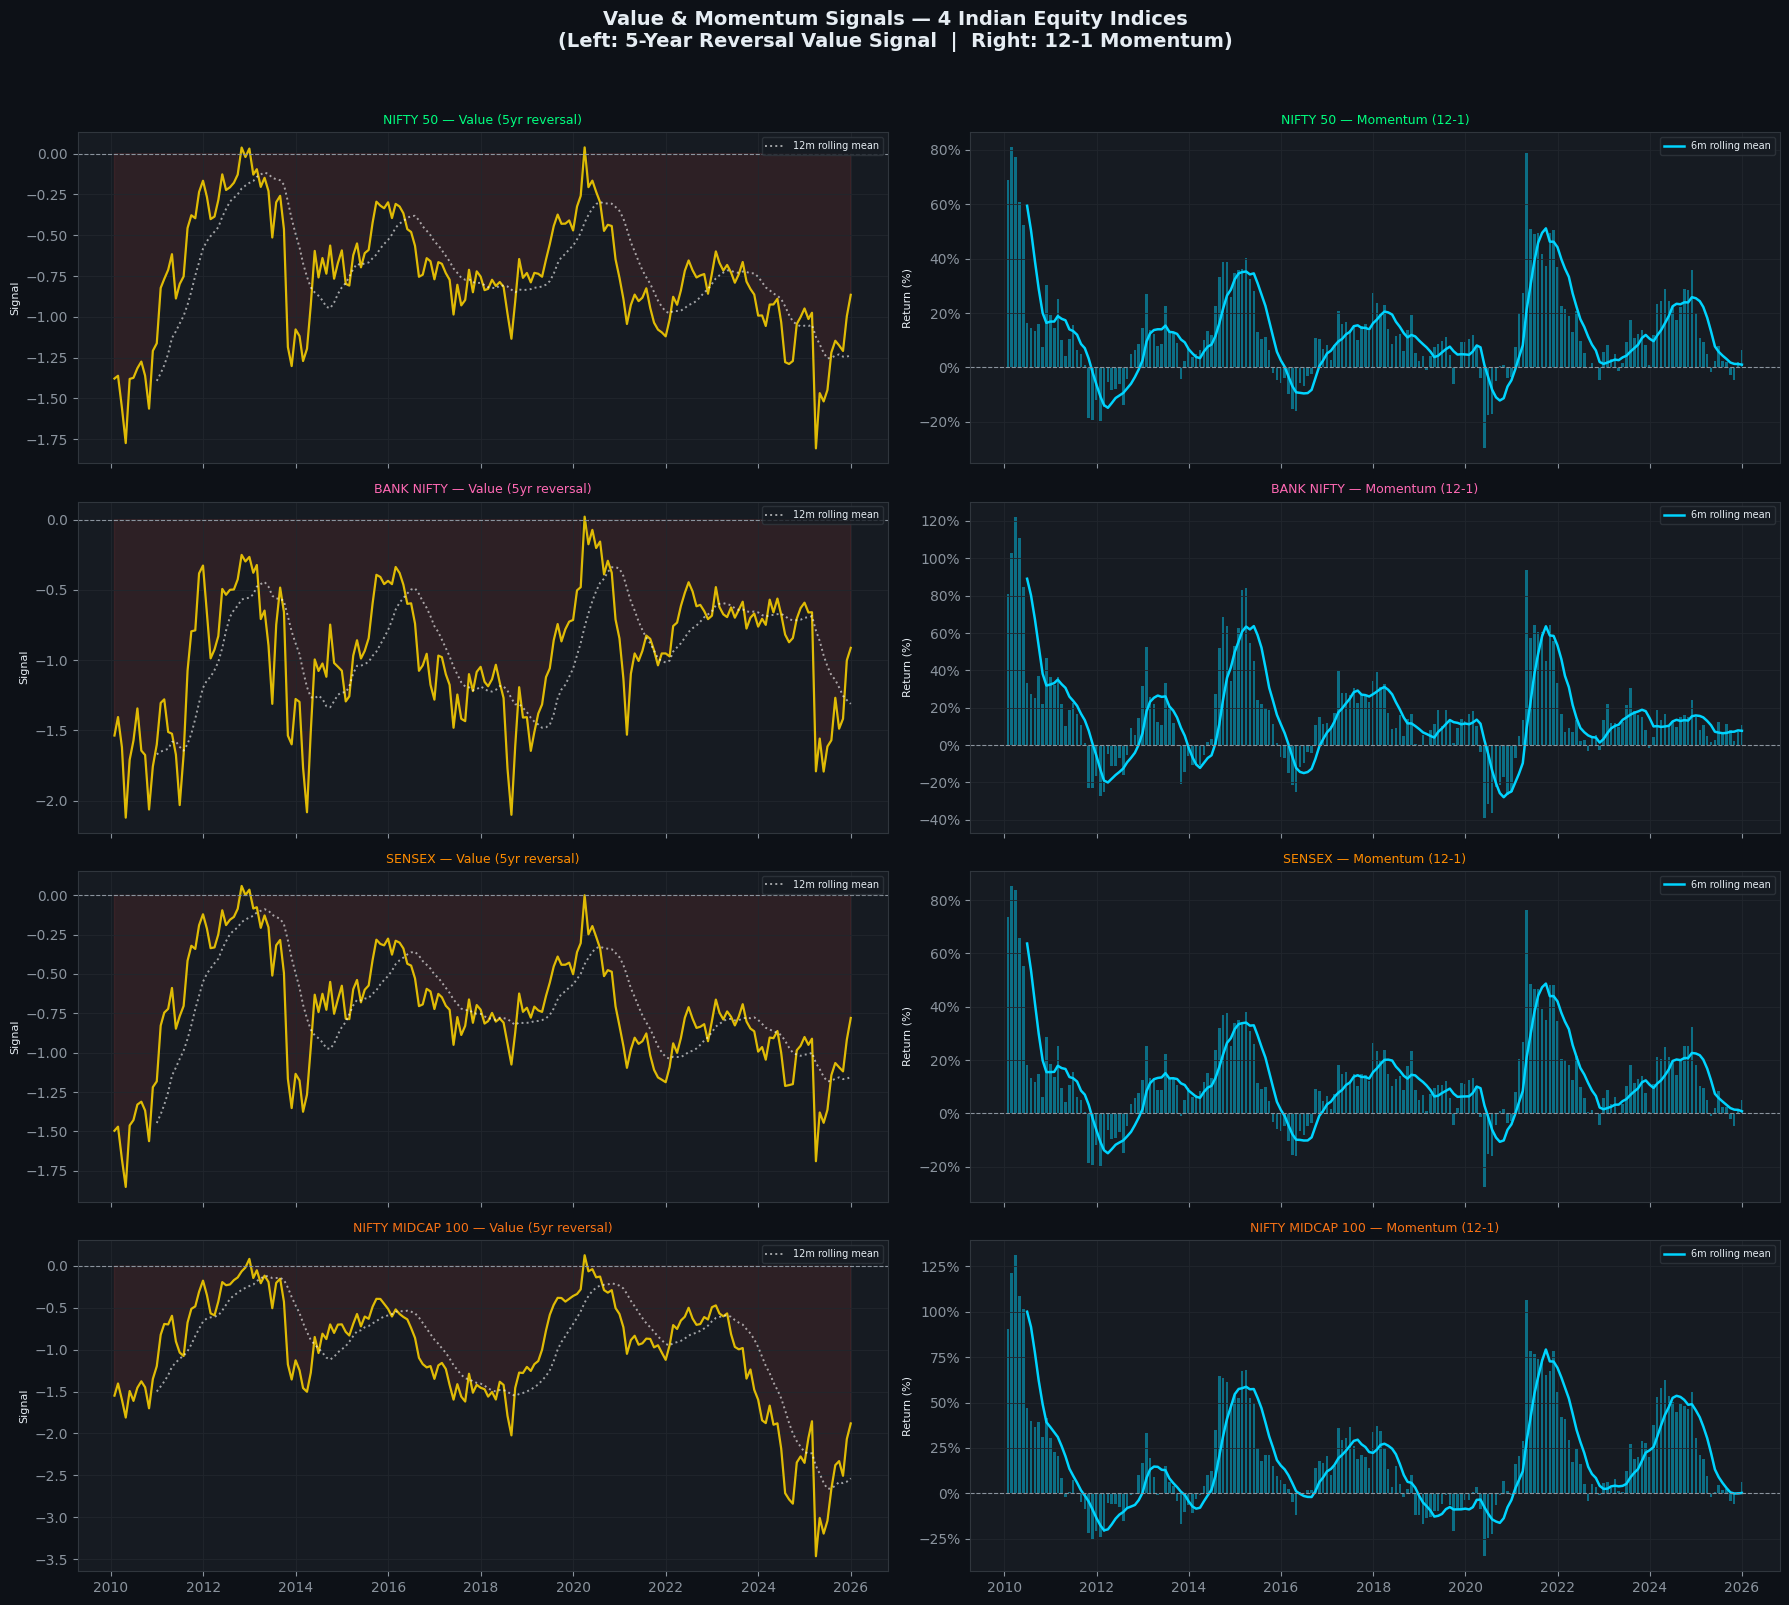

In [6]:
# ── Figure 1: Value & Momentum Signal Time Series ────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(18, 16), sharex='col')  # unpack figure and axes from subplots()
fig.suptitle('Value & Momentum Signals — 4 Indian Equity Indices\n'  # set overall figure title
             '(Left: 5-Year Reversal Value Signal  |  Right: 12-1 Momentum)',
             fontsize=14, fontweight='bold', y=1.0)

for row, (idx, icolor) in enumerate(zip(IDX_NAMES, IDX_COLORS)):
    v_s = val_idx_a[idx].dropna()
    m_s = mom_idx_a[idx].dropna()

    # Value panel
    ax_v = axes[row, 0]
    ax_v.plot(v_s.index, v_s.values, color=C['val'], linewidth=1.6, alpha=0.85)
    ax_v.fill_between(v_s.index, 0, v_s.values,
                      where=(v_s.values >= 0), alpha=0.10, color=C['val'])
    ax_v.fill_between(v_s.index, 0, v_s.values,
                      where=(v_s.values < 0),  alpha=0.10, color=C['neg'])
    ax_v.axhline(0, color=MUTED, linewidth=0.8, linestyle='--')
    ax_v.set_title(f'{idx} — Value (5yr reversal)', fontsize=9, color=icolor)
    ax_v.set_ylabel('Signal', fontsize=8)
    ax_v.grid(True)

    # Rolling mean overlay
    rv = v_s.rolling(12).mean()  # rolling average (smoothed signal)
    ax_v.plot(rv.index, rv.values, color='white', linewidth=1.4, alpha=0.6,
              linestyle=':', label='12m rolling mean')
    ax_v.legend(fontsize=7, loc='upper right')

    # Momentum panel
    ax_m = axes[row, 1]
    ax_m.bar(m_s.index, m_s.values * 100, width=20, alpha=0.45, color=C['mom'])
    ax_m.plot(m_s.index, m_s.rolling(6).mean().values * 100,  # rolling average (smoothed signal)
              color=C['mom'], linewidth=1.8, label='6m rolling mean')
    ax_m.axhline(0, color=MUTED, linewidth=0.8, linestyle='--')
    ax_m.set_title(f'{idx} — Momentum (12-1)', fontsize=9, color=icolor)
    ax_m.set_ylabel('Return (%)', fontsize=8)
    ax_m.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
    ax_m.grid(True)
    ax_m.legend(fontsize=7, loc='upper right')

plt.tight_layout(rect=[0, 0, 1, 0.98])  # auto-adjust subplot spacing
plt.savefig('fig1_signal_timeseries.png', dpi=150, bbox_inches='tight', facecolor=BG)  # save figure to PNG file
plt.show()  # render and display figure

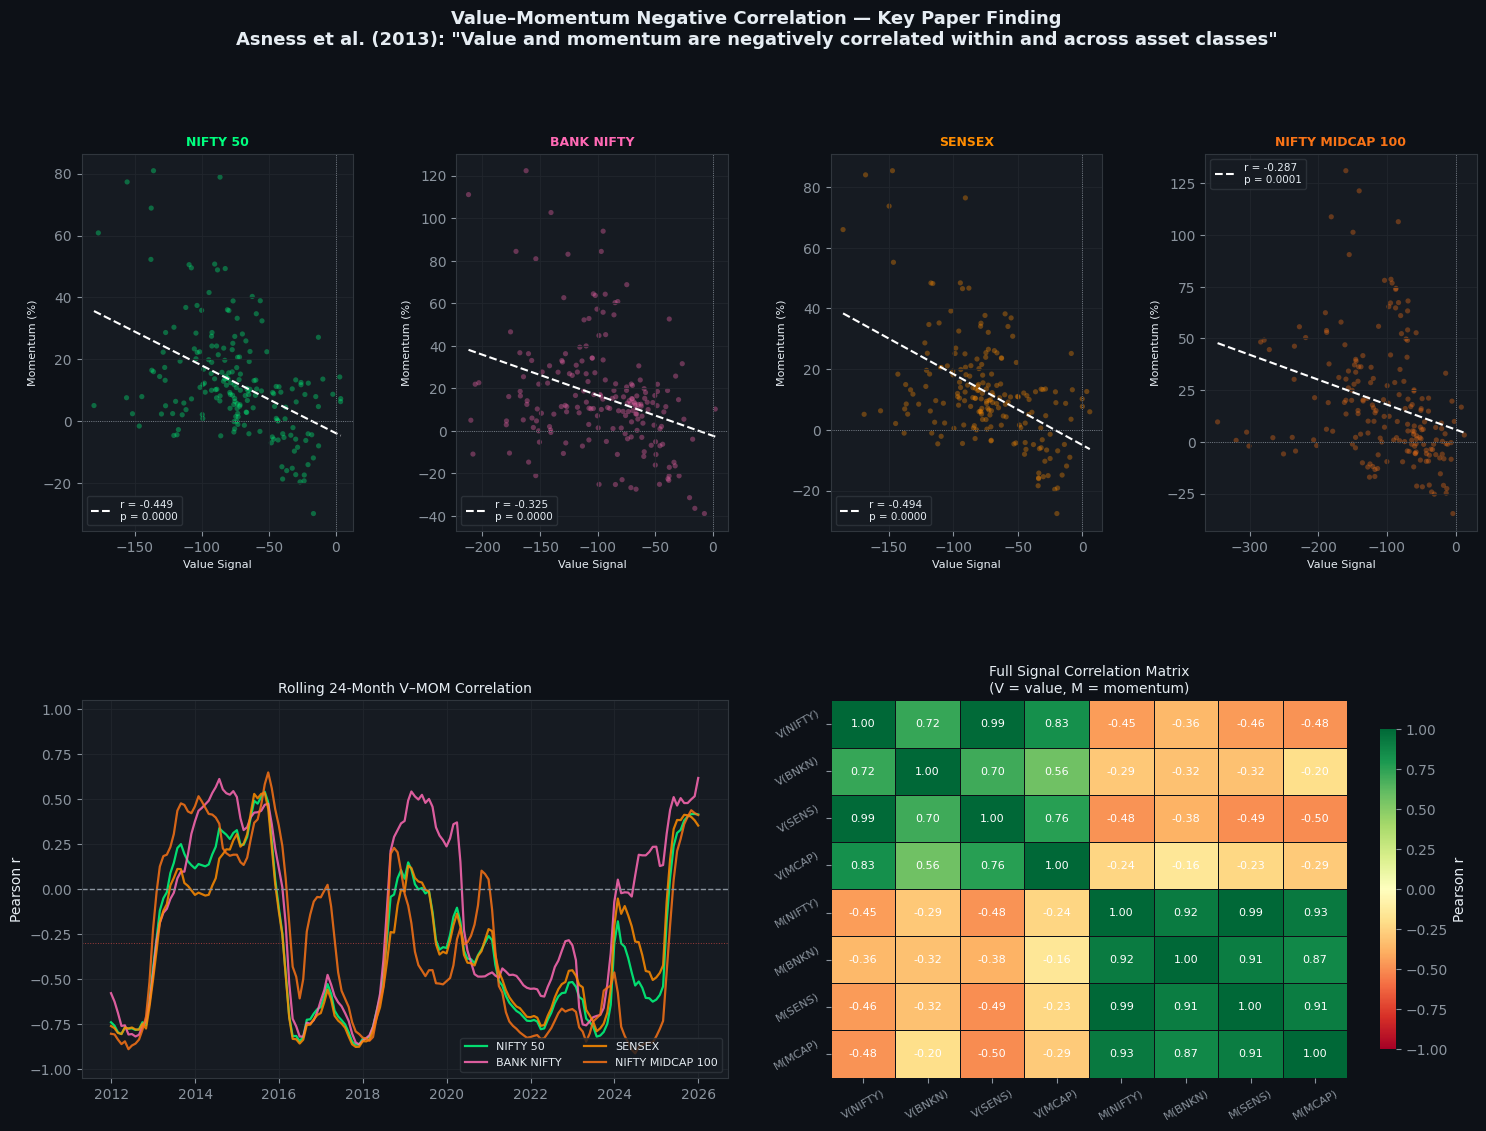

In [7]:
# ── Figure 2: Value–Momentum Negative Correlation (Key Paper Result) ─────────
fig = plt.figure(figsize=(18, 12))  # create new figure
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.38)  # define grid layout for subplots
fig.suptitle('Value–Momentum Negative Correlation — Key Paper Finding\n'  # set overall figure title
             'Asness et al. (2013): "Value and momentum are negatively correlated '
             'within and across asset classes"',
             fontsize=13, fontweight='bold', y=1.0)

# ── Top row: Scatter plots (V vs MOM signal) for each index ──────────────────
for j, (idx, icolor) in enumerate(zip(IDX_NAMES, IDX_COLORS)):
    ax = fig.add_subplot(gs[0, j])
    common = val_idx_a[idx].dropna().index.intersection(mom_idx_a[idx].dropna().index)
    v = val_idx_a.loc[common, idx]
    m = mom_idx_a.loc[common, idx]

    ax.scatter(v.values * 100, m.values * 100,
               s=14, color=icolor, alpha=0.35, edgecolors='none')

    # Regression line
    slope, intercept, rval, pval, _ = stats.linregress(v.values, m.values)
    xs = np.linspace(v.min(), v.max(), 100)
    ax.plot(xs * 100, (slope * xs + intercept) * 100,
            color='white', linewidth=1.5, linestyle='--',
            label=f'r = {rval:.3f}\np = {pval:.4f}')

    ax.axhline(0, color=MUTED, linewidth=0.6, linestyle=':')
    ax.axvline(0, color=MUTED, linewidth=0.6, linestyle=':')
    ax.set_xlabel('Value Signal', fontsize=8)
    ax.set_ylabel('Momentum (%)', fontsize=8)
    ax.set_title(idx, fontsize=9, color=icolor, fontweight='bold')
    ax.legend(fontsize=7.5)
    ax.grid(True)

# ── Bottom-left: Rolling 24-month correlation (V vs MOM for each index) ───────
ax_roll = fig.add_subplot(gs[1, :2])
for idx, icolor in zip(IDX_NAMES, IDX_COLORS):
    common = val_idx_a[idx].dropna().index.intersection(mom_idx_a[idx].dropna().index)
    roll_corr = val_idx_a.loc[common, idx].rolling(24).corr(mom_idx_a.loc[common, idx])  # rolling correlation with market index
    ax_roll.plot(roll_corr.index, roll_corr.values, color=icolor,
                 linewidth=1.6, label=idx, alpha=0.85)

ax_roll.axhline(0,    color=MUTED,    linewidth=1.0, linestyle='--')
ax_roll.axhline(-0.3, color=C['neg'], linewidth=0.7, linestyle=':', alpha=0.6)
ax_roll.set_title('Rolling 24-Month V–MOM Correlation', fontsize=10)
ax_roll.set_ylabel('Pearson r')
ax_roll.set_ylim(-1.05, 1.05)
ax_roll.legend(fontsize=8, ncol=2, loc='lower right')
ax_roll.grid(True)

# ── Bottom-right: Cross-sectional correlation matrix ─────────────────────────
ax_corr = fig.add_subplot(gs[1, 2:])
all_signals = pd.DataFrame({
    'V(NIFTY)' : val_idx_a['NIFTY 50'],
    'V(BNKN)'  : val_idx_a['BANK NIFTY'],
    'V(SENS)'  : val_idx_a['SENSEX'],
    'V(MCAP)'  : val_idx_a['NIFTY MIDCAP 100'],
    'M(NIFTY)' : mom_idx_a['NIFTY 50'],
    'M(BNKN)'  : mom_idx_a['BANK NIFTY'],
    'M(SENS)'  : mom_idx_a['SENSEX'],
    'M(MCAP)'  : mom_idx_a['NIFTY MIDCAP 100'],
}).dropna()

corr_mat = all_signals.corr()
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdYlGn',  # draw annotated correlation heatmap
            center=0, vmin=-1, vmax=1, ax=ax_corr,
            linewidths=0.5, linecolor=BG,
            annot_kws={'size': 8, 'color': 'white'},
            cbar_kws={'label': 'Pearson r', 'shrink': 0.85})
ax_corr.set_title('Full Signal Correlation Matrix\n(V = value, M = momentum)', fontsize=10)
ax_corr.tick_params(labelsize=8, rotation=30)

plt.savefig('fig2_vmom_correlation.png', dpi=150, bbox_inches='tight', facecolor=BG)  # save figure to PNG file
plt.show()  # render and display figure

In [8]:
# ── Tercile Portfolio Sort (P1 = low signal, P3 = high signal) ────────────────
def tercile_sort(ret_df, signal_df, label=''):  # define function tercile_sort()
    # Monthly equal-weight tercile portfolios using lagged signal.
    p_rets = {1:[], 2:[], 3:[]}
    dates  = []
    ret_dates = ret_df.index
    for i in range(1, len(ret_dates)):  # iterate over each element
        date, prev = ret_dates[i], ret_dates[i-1]
        if prev not in signal_df.index:  # conditional branch
            continue  # skip to next loop iteration
        r = ret_df.loc[date].dropna()
        s = signal_df.loc[prev].reindex(r.index).dropna()
        common = r.index.intersection(s.index)
        if len(common) < 9:  # conditional branch
            continue  # skip to next loop iteration
        r_c, s_c = r[common], s[common]
        ranks = pd.qcut(s_c.rank(method='first'), 3, labels=[1, 2, 3])
        for p in [1, 2, 3]:  # iterate over each element
            p_rets[p].append(r_c[ranks == p].mean())
        dates.append(date)
    df = pd.DataFrame({'P1':p_rets[1], 'P2':p_rets[2], 'P3':p_rets[3]}, index=dates)
    df['P3-P1'] = df['P3'] - df['P1']
    return df  # return computed result to caller

# ── Signal-weighted zero-cost factor (Eq. 1–2 in paper) ──────────────────────
def sig_weighted_factor(ret_df, signal_df, label=''):  # define function sig_weighted_factor()
    # w_it = c_t*(rank(S_it) - mean_rank). Scaled: long=$1, short=-$1.
    f_rets, dates = [], []
    ret_dates = ret_df.index
    for i in range(1, len(ret_dates)):  # iterate over each element
        date, prev = ret_dates[i], ret_dates[i-1]
        if prev not in signal_df.index:  # conditional branch
            continue  # skip to next loop iteration
        r = ret_df.loc[date].dropna()
        s = signal_df.loc[prev].reindex(r.index).dropna()
        common = r.index.intersection(s.index)
        if len(common) < 5:  # conditional branch
            continue  # skip to next loop iteration
        r_c, s_c = r[common], s[common]
        ranks  = s_c.rank()  # assign ordinal ranks within cross-section
        dem    = ranks - ranks.mean()  # equal-weight portfolio (average return)
        pos_sum = dem[dem > 0].sum()
        if pos_sum < 1e-8:  # conditional branch
            continue  # skip to next loop iteration
        w = dem / pos_sum
        f_rets.append((w * r_c).sum())
        dates.append(date)
    return pd.Series(f_rets, index=dates, name=label)  # return computed result to caller

print('Running portfolio sorts and constructing factors...')  # display output / progress message

# Tercile sorts
val_ports   = tercile_sort(stock_ret, val_z_stock,   'Value')
mom_ports   = tercile_sort(stock_ret, mom_z_stock,   'Momentum')
combo_ports = tercile_sort(stock_ret, combo_z_stock, 'Combo')

# Signal-weighted factors (paper eq. 1-2)
val_factor   = sig_weighted_factor(stock_ret, val_z_stock,   'VAL')
mom_factor   = sig_weighted_factor(stock_ret, mom_z_stock,   'MOM')
combo_factor = 0.5 * val_factor + 0.5 * mom_factor
combo_factor.name = 'COMBO'

# Align
common_f = val_factor.index.intersection(mom_factor.index)
factors  = pd.DataFrame({'VAL': val_factor, 'MOM': mom_factor,
                          'COMBO': combo_factor}).loc[common_f].dropna()

print(f'✓ Portfolio sorts: {len(val_ports)} months')  # display output / progress message
print(f'  Tercile portfolios: V | MOM | Combo')  # display output / progress message
print(f'  Signal-weighted factors: {len(factors)} months  [{factors.index[0].date()} → {factors.index[-1].date()}]')  # display output / progress message

Running portfolio sorts and constructing factors...
✓ Portfolio sorts: 250 months
  Tercile portfolios: V | MOM | Combo
  Signal-weighted factors: 238 months  [2006-03-31 → 2025-12-31]


In [9]:
# ── Factor + Portfolio Statistics (mirroring Table I of paper) ───────────────
def port_stats(ret_series, rf=RF_MONTHLY):  # define function port_stats()
    s = ret_series.dropna()
    excess = s - rf
    t_stat, p_val = stats.ttest_1samp(s, 0)
    sharpe = excess.mean() / excess.std() * np.sqrt(12)
    return {  # return computed result to caller
        'Mean (Ann.)': f'{s.mean()*12*100:+.2f}%',
        'Vol  (Ann.)': f'{s.std()*np.sqrt(12)*100:.2f}%',
        'Sharpe'     : f'{sharpe:.3f}',
        't-stat'     : f'{t_stat:.3f}',
        'p-value'    : f'{p_val:.4f}',
        'Sig. 5%'    : '✓' if p_val < 0.05 else '✗',
    }

print('═' * 72)  # display output / progress message
print('    FAMA-FRENCH STYLE VALUE + MOMENTUM PORTFOLIO STATISTICS')  # display output / progress message
print('═' * 72)  # display output / progress message
print('\n── Tercile Sort P3-P1 Spread Portfolios ──')  # display output / progress message
for label, ports in [('Value (V)', val_ports), ('Momentum (MOM)', mom_ports), ('Combo (50/50)', combo_ports)]:
    s = ports['P3-P1']
    st = port_stats(s)
    print(f'  {label:<20} Ann={st["Mean (Ann.)"]:<9} Vol={st["Vol  (Ann.)"]:<8} '  # display output / progress message
          f'Sharpe={st["Sharpe"]:<7} t={st["t-stat"]:<7} p={st["p-value"]}  {st["Sig. 5%"]}')

print('\n── Signal-Weighted Factors (Eq. 1-2, Paper) ──')  # display output / progress message
for col, color in [('VAL', 'gold'), ('MOM', 'cyan'), ('COMBO', 'violet')]:
    s = factors[col]
    st = port_stats(s)
    print(f'  {col:<10} Ann={st["Mean (Ann.)"]:<9} Vol={st["Vol  (Ann.)"]:<8} '  # display output / progress message
          f'Sharpe={st["Sharpe"]:<7} t={st["t-stat"]:<7} p={st["p-value"]}  {st["Sig. 5%"]}')

print()  # display output / progress message
v_m_corr = factors['VAL'].corr(factors['MOM'])
print(f'  V–MOM factor correlation: {v_m_corr:+.4f}  '  # display output / progress message
      f'({"✓ NEGATIVE — consistent with paper" if v_m_corr < 0 else "✗ Unexpected positive"})')
print('═' * 72)  # display output / progress message

════════════════════════════════════════════════════════════════════════
    FAMA-FRENCH STYLE VALUE + MOMENTUM PORTFOLIO STATISTICS
════════════════════════════════════════════════════════════════════════

── Tercile Sort P3-P1 Spread Portfolios ──
  Value (V)            Ann=-20.31%   Vol=78.70%   Sharpe=-0.332  t=-1.178  p=0.2398  ✗
  Momentum (MOM)       Ann=+6.52%    Vol=19.12%   Sharpe=0.035   t=1.518   p=0.1304  ✗
  Combo (50/50)        Ann=-15.70%   Vol=83.21%   Sharpe=-0.259  t=-0.840  p=0.4017  ✗

── Signal-Weighted Factors (Eq. 1-2, Paper) ──
  VAL        Ann=-24.15%   Vol=99.77%   Sharpe=-0.301  t=-1.078  p=0.2822  ✗
  MOM        Ann=+2.50%    Vol=26.04%   Sharpe=-0.128  t=0.428   p=0.6693  ✗
  COMBO      Ann=-10.82%   Vol=57.82%   Sharpe=-0.288  t=-0.834  p=0.4053  ✗

  V–MOM factor correlation: +0.5276  (✗ Unexpected positive)
════════════════════════════════════════════════════════════════════════


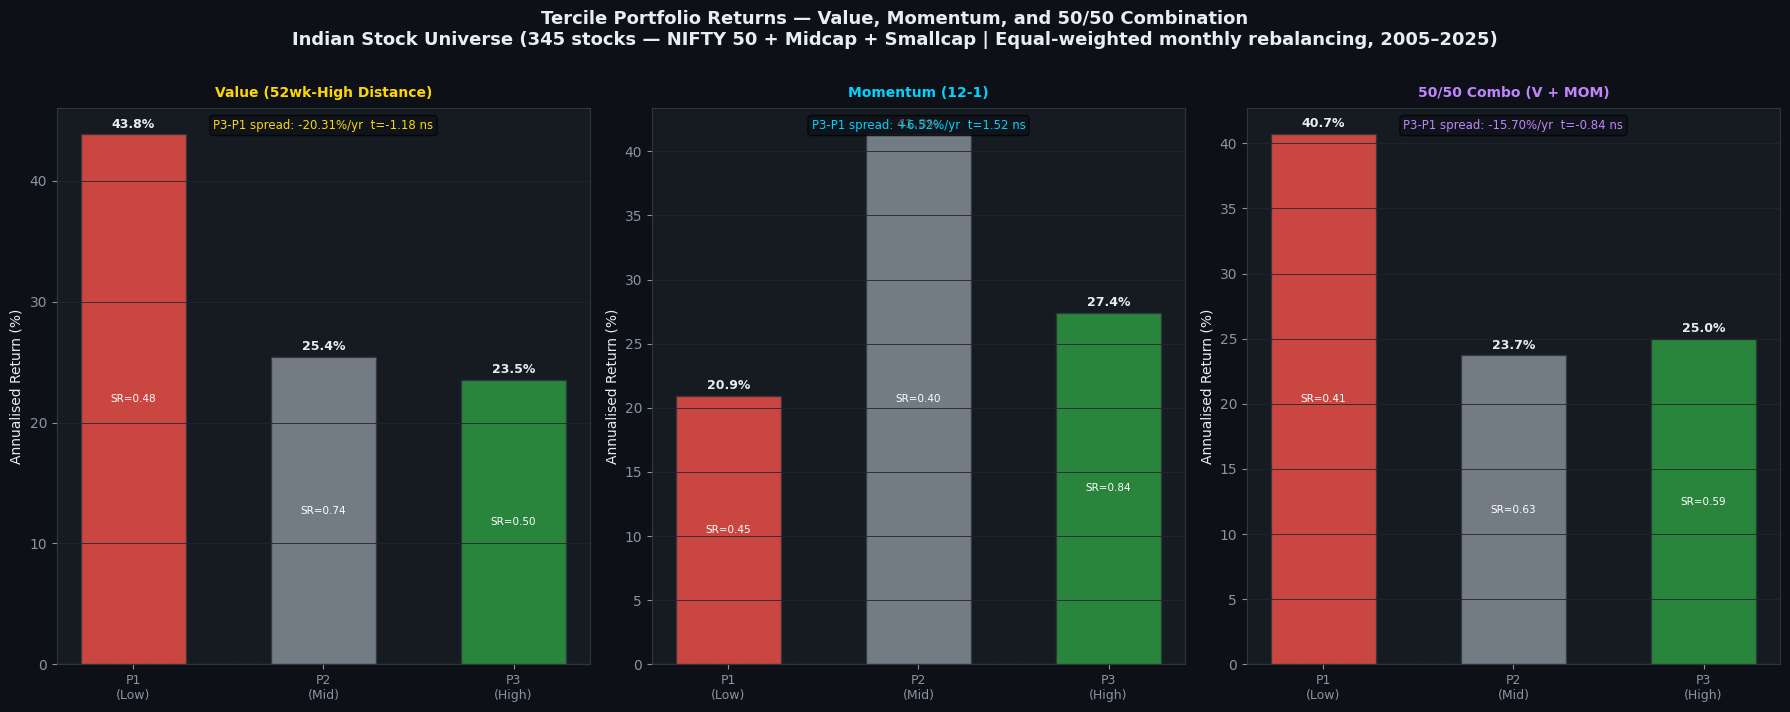

In [10]:
# ── Figure 3: Portfolio Sort Performance (P1 / P2 / P3 bar chart) ─────────────
n_stocks = stock_ret.shape[1]
fig, axes = plt.subplots(1, 3, figsize=(18, 7))  # unpack figure and axes from subplots()
fig.suptitle(f'Tercile Portfolio Returns — Value, Momentum, and 50/50 Combination\n'  # set overall figure title
             f'Indian Stock Universe ({n_stocks} stocks — NIFTY 50 + Midcap + Smallcap | Equal-weighted monthly rebalancing, 2005–2025)',
             fontsize=13, fontweight='bold', y=1.01)

configs = [
    ('Value (52wk-High Distance)',    val_ports,   C['val'],   'V'),
    ('Momentum (12-1)',               mom_ports,   C['mom'],   'MOM'),
    ('50/50 Combo (V + MOM)',         combo_ports, C['combo'], 'C'),
]

for ax, (title, ports, color, tag) in zip(axes, configs):
    means = {p: ports[p].mean() * 12 * 100 for p in ['P1', 'P2', 'P3']}
    sharpes = {p: (ports[p].mean() - RF_MONTHLY) / ports[p].std() * np.sqrt(12)  # risk-free rate constant (India T-Bill proxy)
               for p in ['P1', 'P2', 'P3']}  # iterate over each element
    spread  = ports['P3-P1'].mean() * 12 * 100
    t_stat, p_val = stats.ttest_1samp(ports['P3-P1'].dropna(), 0)

    xs = np.arange(3)
    bar_cols = [C['neg'], MUTED, C['pos']]
    bars = ax.bar(xs, [means['P1'], means['P2'], means['P3']],
                  color=bar_cols, alpha=0.8, edgecolor=BORDER, width=0.55)

    # Annotate bars
    for bar, v, s in zip(bars, means.values(), sharpes.values()):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3, f'{v:.1f}%', ha='center', va='bottom',
                fontsize=9, color=TEXT, fontweight='bold')
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height()/2, f'SR={s:.2f}', ha='center', va='center',
                fontsize=7.5, color='white')

    ax.axhline(0, color=MUTED, linewidth=0.8, linestyle='--')
    ax.set_xticks(xs)
    ax.set_xticklabels(['P1\n(Low)', 'P2\n(Mid)', 'P3\n(High)'], fontsize=9)
    ax.set_title(title, fontsize=10, color=color, fontweight='bold', pad=8)
    ax.set_ylabel('Annualised Return (%)')
    ax.grid(True, axis='y')

    sig = '***' if p_val<0.01 else ('**' if p_val<0.05 else ('*' if p_val<0.10 else 'ns'))
    ax.text(0.5, 0.98, f'P3-P1 spread: {spread:+.2f}%/yr  t={t_stat:.2f} {sig}',
            transform=ax.transAxes, ha='center', va='top', fontsize=8.5,
            color=color, bbox=dict(boxstyle='round', facecolor=BG, alpha=0.7))

plt.tight_layout()  # auto-adjust subplot spacing
plt.savefig('fig3_portfolio_sorts.png', dpi=150, bbox_inches='tight', facecolor=BG)  # save figure to PNG file
plt.show()  # render and display figure

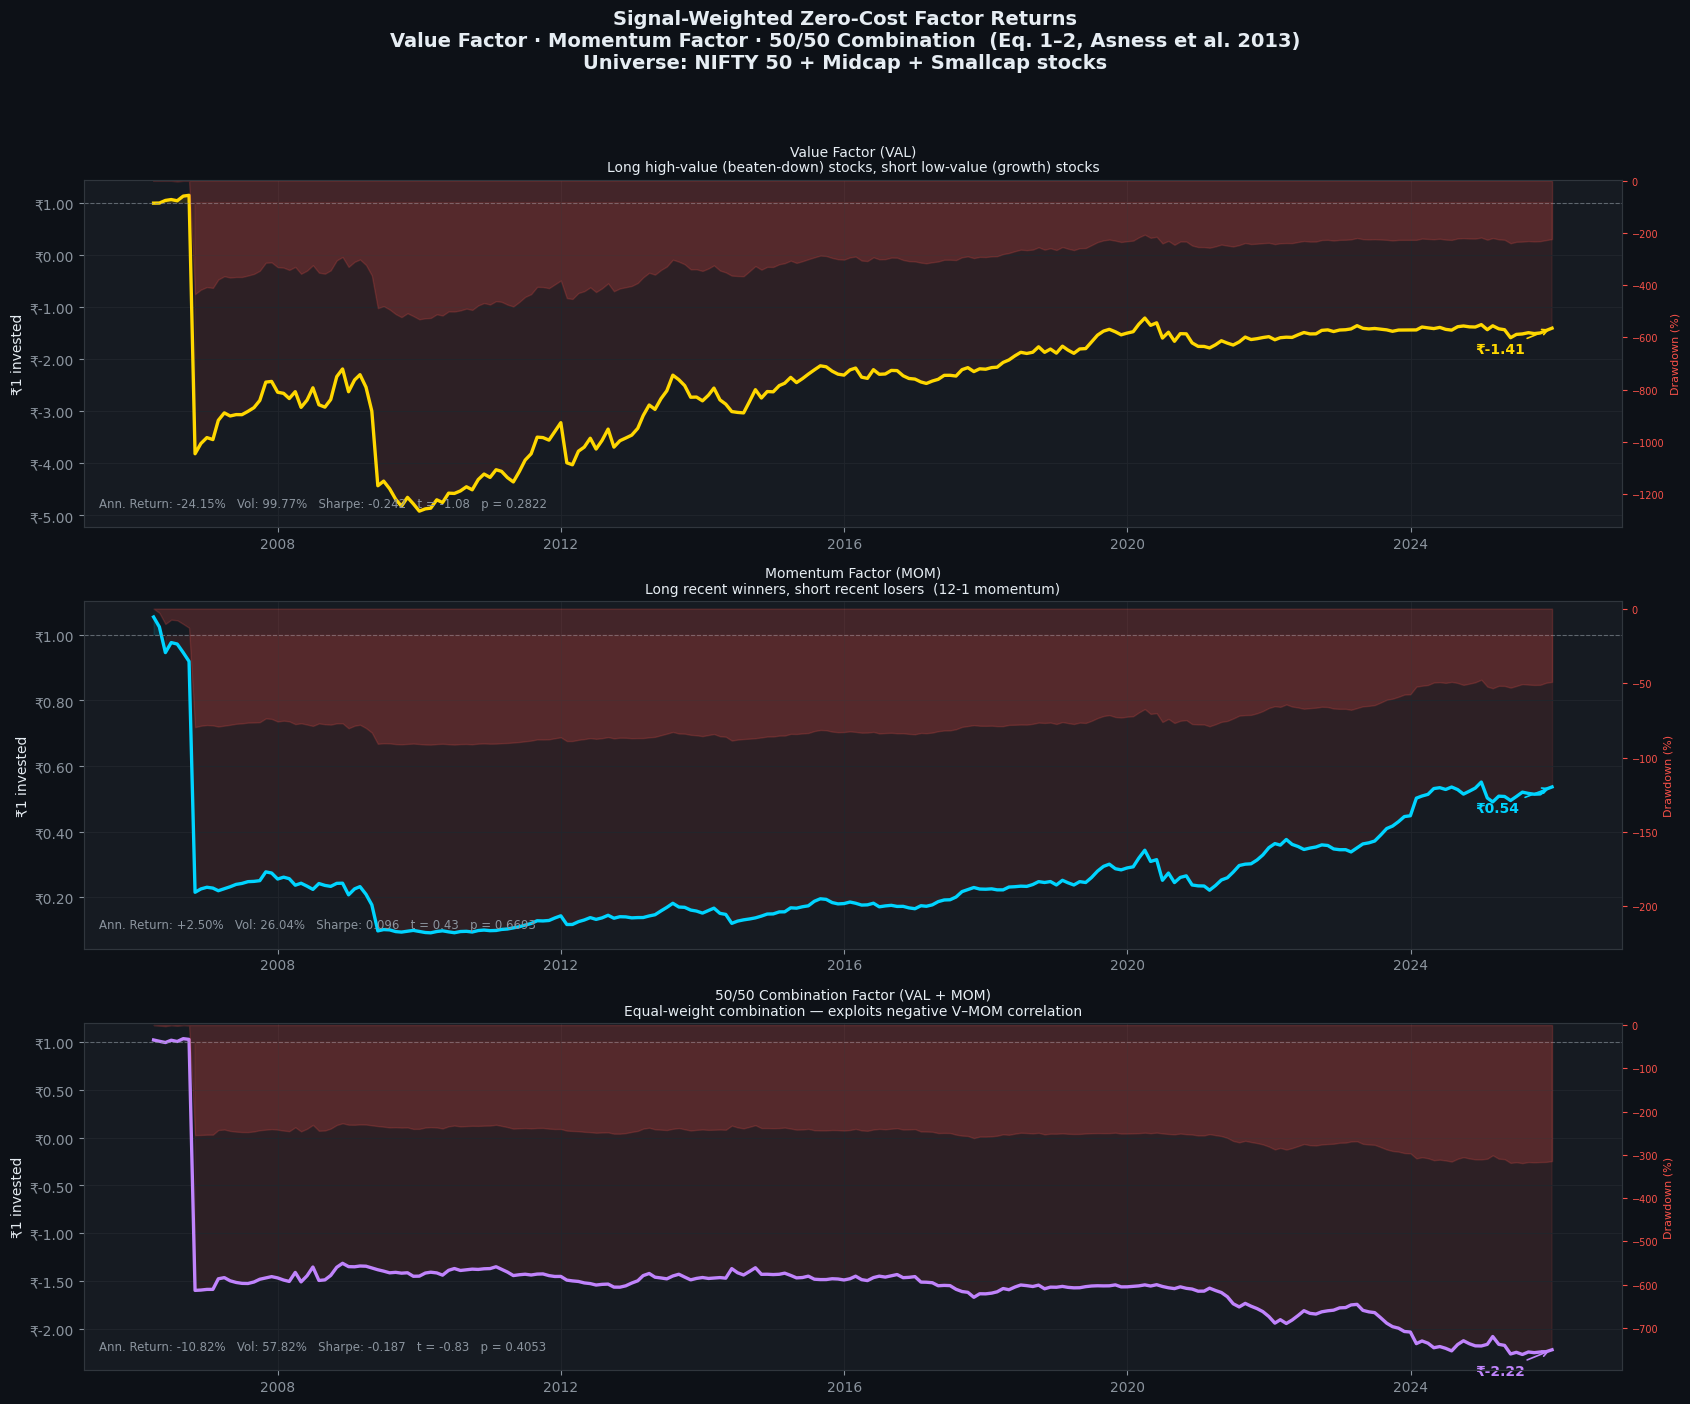

In [11]:
# ── Figure 4: Cumulative Returns — VAL, MOM, COMBO Factors ───────────────────
fig, axes = plt.subplots(3, 1, figsize=(17, 14))  # unpack figure and axes from subplots()
fig.suptitle('Signal-Weighted Zero-Cost Factor Returns\n'  # set overall figure title
             'Value Factor · Momentum Factor · 50/50 Combination  (Eq. 1–2, Asness et al. 2013)\n'
             f'Universe: NIFTY 50 + Midcap + Smallcap stocks',
             fontsize=14, fontweight='bold', y=1.0)

factor_meta = [
    ('VAL',   C['val'],   'Value Factor (VAL)',
     'Long high-value (beaten-down) stocks, short low-value (growth) stocks'),
    ('MOM',   C['mom'],   'Momentum Factor (MOM)',
     'Long recent winners, short recent losers  (12-1 momentum)'),
    ('COMBO', C['combo'], '50/50 Combination Factor (VAL + MOM)',
     'Equal-weight combination — exploits negative V–MOM correlation'),
]

cum_f = (1 + factors).cumprod()  # cumulate returns into a wealth index

for ax, (col, color, title, subtitle) in zip(axes, factor_meta):
    y = cum_f[col]
    ax.plot(y.index, y.values, color=color, linewidth=2.4, label=col)
    ax.axhline(1, color=MUTED, linewidth=0.8, linestyle='--', alpha=0.6)
    ax.fill_between(y.index, 1, y.values, where=(y.values >= 1),
                    alpha=0.10, color=color)
    ax.fill_between(y.index, 1, y.values, where=(y.values < 1),
                    alpha=0.10, color=C['neg'])

    # Max drawdown shading
    running_max = y.cummax()  # track the running peak value
    dd = (y / running_max - 1) * 100
    ax2 = ax.twinx()
    ax2.fill_between(dd.index, 0, dd.values, alpha=0.20, color=C['neg'])
    ax2.set_ylabel('Drawdown (%)', color=C['neg'], fontsize=8)
    ax2.tick_params(colors=C['neg'], labelsize=7)
    ax2.set_ylim(dd.min() * 2.5, 5)

    # Final annotation
    final = y.iloc[-1]
    ax.annotate(f'₹{final:.2f}',
                xy=(y.index[-1], final),
                xytext=(-55, 8 if final > 1 else -18), textcoords='offset points',
                color=color, fontsize=10, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2))

    # Stats box
    ann_ret = factors[col].mean() * 12 * 100
    ann_vol = factors[col].std() * np.sqrt(12) * 100
    sharpe  = factors[col].mean() / factors[col].std() * np.sqrt(12)
    t_s, p_v = stats.ttest_1samp(factors[col].dropna(), 0)
    ax.text(0.01, 0.05,
            f'Ann. Return: {ann_ret:+.2f}%   Vol: {ann_vol:.2f}%   '
            f'Sharpe: {sharpe:.3f}   t = {t_s:.2f}   p = {p_v:.4f}',
            transform=ax.transAxes, fontsize=8.5, color=MUTED, va='bottom')
    ax.set_title(f'{title}\n{subtitle}', fontsize=10, pad=6)
    ax.set_ylabel('₹1 invested')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.2f}'))
    ax.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.97])  # auto-adjust subplot spacing
plt.savefig('fig4_cumulative_factors.png', dpi=150, bbox_inches='tight', facecolor=BG)  # save figure to PNG file
plt.show()  # render and display figure

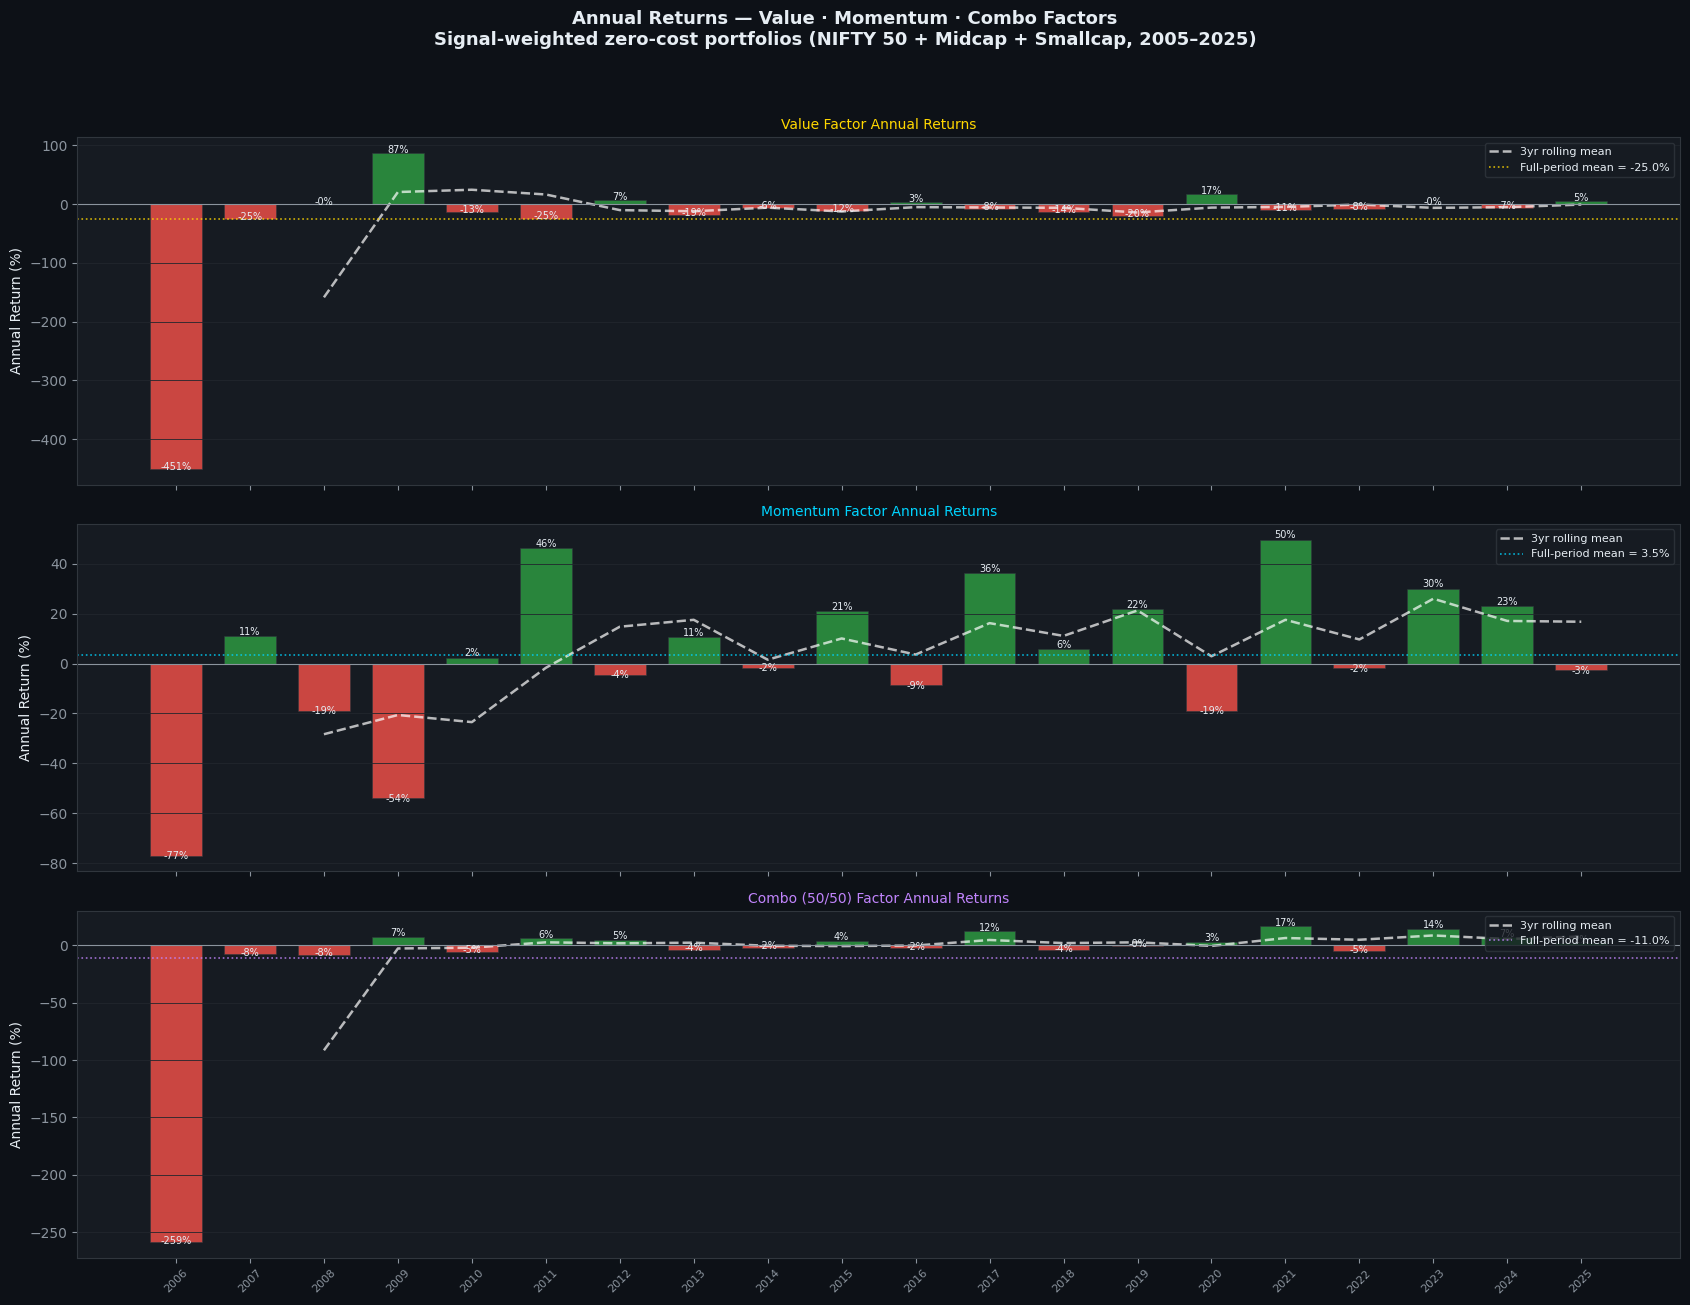

In [12]:
# ── Figure 5: Annual Factor Returns ──────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(17, 13), sharex=True)  # unpack figure and axes from subplots()
fig.suptitle('Annual Returns — Value · Momentum · Combo Factors\n'  # set overall figure title
             f'Signal-weighted zero-cost portfolios (NIFTY 50 + Midcap + Smallcap, 2005–2025)',
             fontsize=13, fontweight='bold', y=1.0)

annual_f = factors.resample('YE').apply(lambda x: (1 + x).prod() - 1) * 100
years    = annual_f.index.year

f_meta = [('VAL', C['val'], 'Value Factor Annual Returns'),
          ('MOM', C['mom'], 'Momentum Factor Annual Returns'),
          ('COMBO', C['combo'], 'Combo (50/50) Factor Annual Returns')]

for ax, (col, color, title) in zip(axes, f_meta):
    y    = annual_f[col].values
    cols = [C['pos'] if v >= 0 else C['neg'] for v in y]
    ax.bar(years, y, color=cols, alpha=0.8, edgecolor=BORDER, linewidth=0.5, width=0.7)

    # Rolling 3-year mean
    roll3 = annual_f[col].rolling(3).mean()  # rolling average (smoothed signal)
    ax.plot(roll3.index.year, roll3.values,
            color='white', linewidth=1.8, linestyle='--', alpha=0.7, label='3yr rolling mean')

    ax.axhline(0, color=MUTED, linewidth=0.8, linestyle='-')
    ax.axhline(annual_f[col].mean(), color=color, linewidth=1.2, linestyle=':',
               alpha=0.8, label=f'Full-period mean = {annual_f[col].mean():.1f}%')

    for xi, yi in zip(years, y):
        ax.text(xi, yi + (0.5 if yi >= 0 else -1.5),
                f'{yi:.0f}%', ha='center', fontsize=7, color=TEXT)

    ax.set_title(title, fontsize=10, color=color)
    ax.set_ylabel('Annual Return (%)')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, axis='y')
    ax.set_xticks(years)
    ax.set_xticklabels(years, rotation=45, fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.97])  # auto-adjust subplot spacing
plt.savefig('fig5_annual_returns.png', dpi=150, bbox_inches='tight', facecolor=BG)  # save figure to PNG file
plt.show()  # render and display figure

In [13]:
# ── Index-level Cross-Sectional Strategy (median split: long top 2, short bottom 2) ──
def idx_longshort(ret_df, signal_df, label=''):  # define function idx_longshort()
    # For each month, rank 4 indices by lagged signal, long top 2 short bottom 2.
    ls, dates = [], []
    ret_dates = ret_df.index
    for i in range(1, len(ret_dates)):  # iterate over each element
        date, prev = ret_dates[i], ret_dates[i-1]
        if prev not in signal_df.index:  # conditional branch
            continue  # skip to next loop iteration
        r = ret_df.loc[date].dropna()
        s = signal_df.loc[prev].reindex(r.index).dropna()
        common = r.index.intersection(s.index)
        if len(common) < 2:  # conditional branch
            continue  # skip to next loop iteration
        r_c, s_c = r[common], s[common]
        med = s_c.median()
        long_r  = r_c[s_c >= med].mean()  # equal-weight portfolio (average return)
        short_r = r_c[s_c <  med].mean()  # equal-weight portfolio (average return)
        ls.append(long_r - short_r)
        dates.append(date)
    return pd.Series(ls, index=dates, name=label)  # return computed result to caller

# Align index signals with returns
common_idx_dates = idx_val_z.index.intersection(idx_mom_z.index).intersection(idx_ret_df.dropna(how='all').index)
iv_z  = idx_val_z.loc[common_idx_dates]
im_z  = idx_mom_z.loc[common_idx_dates]
ic_z  = idx_combo_z.loc[common_idx_dates]
ir_df = idx_ret_df.loc[common_idx_dates]

idx_val_ls   = idx_longshort(ir_df, iv_z,   'Idx-VAL')
idx_mom_ls   = idx_longshort(ir_df, im_z,   'Idx-MOM')
idx_combo_ls = idx_longshort(ir_df, ic_z,   'Idx-COMBO')

# Combine
idx_strategies = pd.DataFrame({
    'VAL'  : idx_val_ls,
    'MOM'  : idx_mom_ls,
    'COMBO': idx_combo_ls,
}).dropna()

print('Index-level cross-sectional strategy statistics:')  # display output / progress message
print('═' * 58)  # display output / progress message
for col, color_name in [('VAL','Value'), ('MOM','Momentum'), ('COMBO','Combo')]:
    s = idx_strategies[col].dropna()
    t_s, p_v = stats.ttest_1samp(s, 0)
    sr = s.mean() / s.std() * np.sqrt(12)
    print(f'  {color_name:<12} Ann={s.mean()*12*100:+.2f}%  '  # display output / progress message
          f'Sharpe={sr:.3f}  t={t_s:.3f}  p={p_v:.4f}  '
          f'{"✓" if p_v<0.05 else "✗"}')
print()  # display output / progress message
print(f'  V–MOM corr (index-level): {idx_strategies["VAL"].corr(idx_strategies["MOM"]):+.4f}')  # display output / progress message
print('═' * 58)  # display output / progress message

Index-level cross-sectional strategy statistics:
══════════════════════════════════════════════════════════
  Value        Ann=-0.04%  Sharpe=-0.004  t=-0.016  p=0.9870  ✗
  Momentum     Ann=-0.75%  Sharpe=-0.087  t=-0.346  p=0.7297  ✗
  Combo        Ann=-0.74%  Sharpe=-0.081  t=-0.325  p=0.7455  ✗

  V–MOM corr (index-level): -0.0556
══════════════════════════════════════════════════════════


══════════════════════════════════════════════════════════════════════════════════
   DRAWDOWN STATISTICS — ALL STRATEGIES (VALUE + MOMENTUM)
══════════════════════════════════════════════════════════════════════════════════
  Strategy                 MDD (%)  Avg DD (%)   Calmar  Max Recov.  Ulcer Idx
  ────────────────────────────────────────────────────────────────────────────
  ── Tercile spreads ──
    Value P3-P1          -400.47   -227.37       -0.051         244     241.57
    Momentum P3-P1       -62.88    -24.50         0.104         134      29.64
    Combo P3-P1          -461.08   -333.41       -0.034         231     335.20

  ── Signal-weighted factors ──
    VAL factor           -517.05   -289.69       -0.046         244     308.04
    MOM factor           -91.35    -75.05         0.027         237      76.51
    COMBO factor         -319.00   -250.01       -0.034         232     252.68

  ── Index cross-section ──
    Idx-VAL              -41.72    -19.99        -0.001  

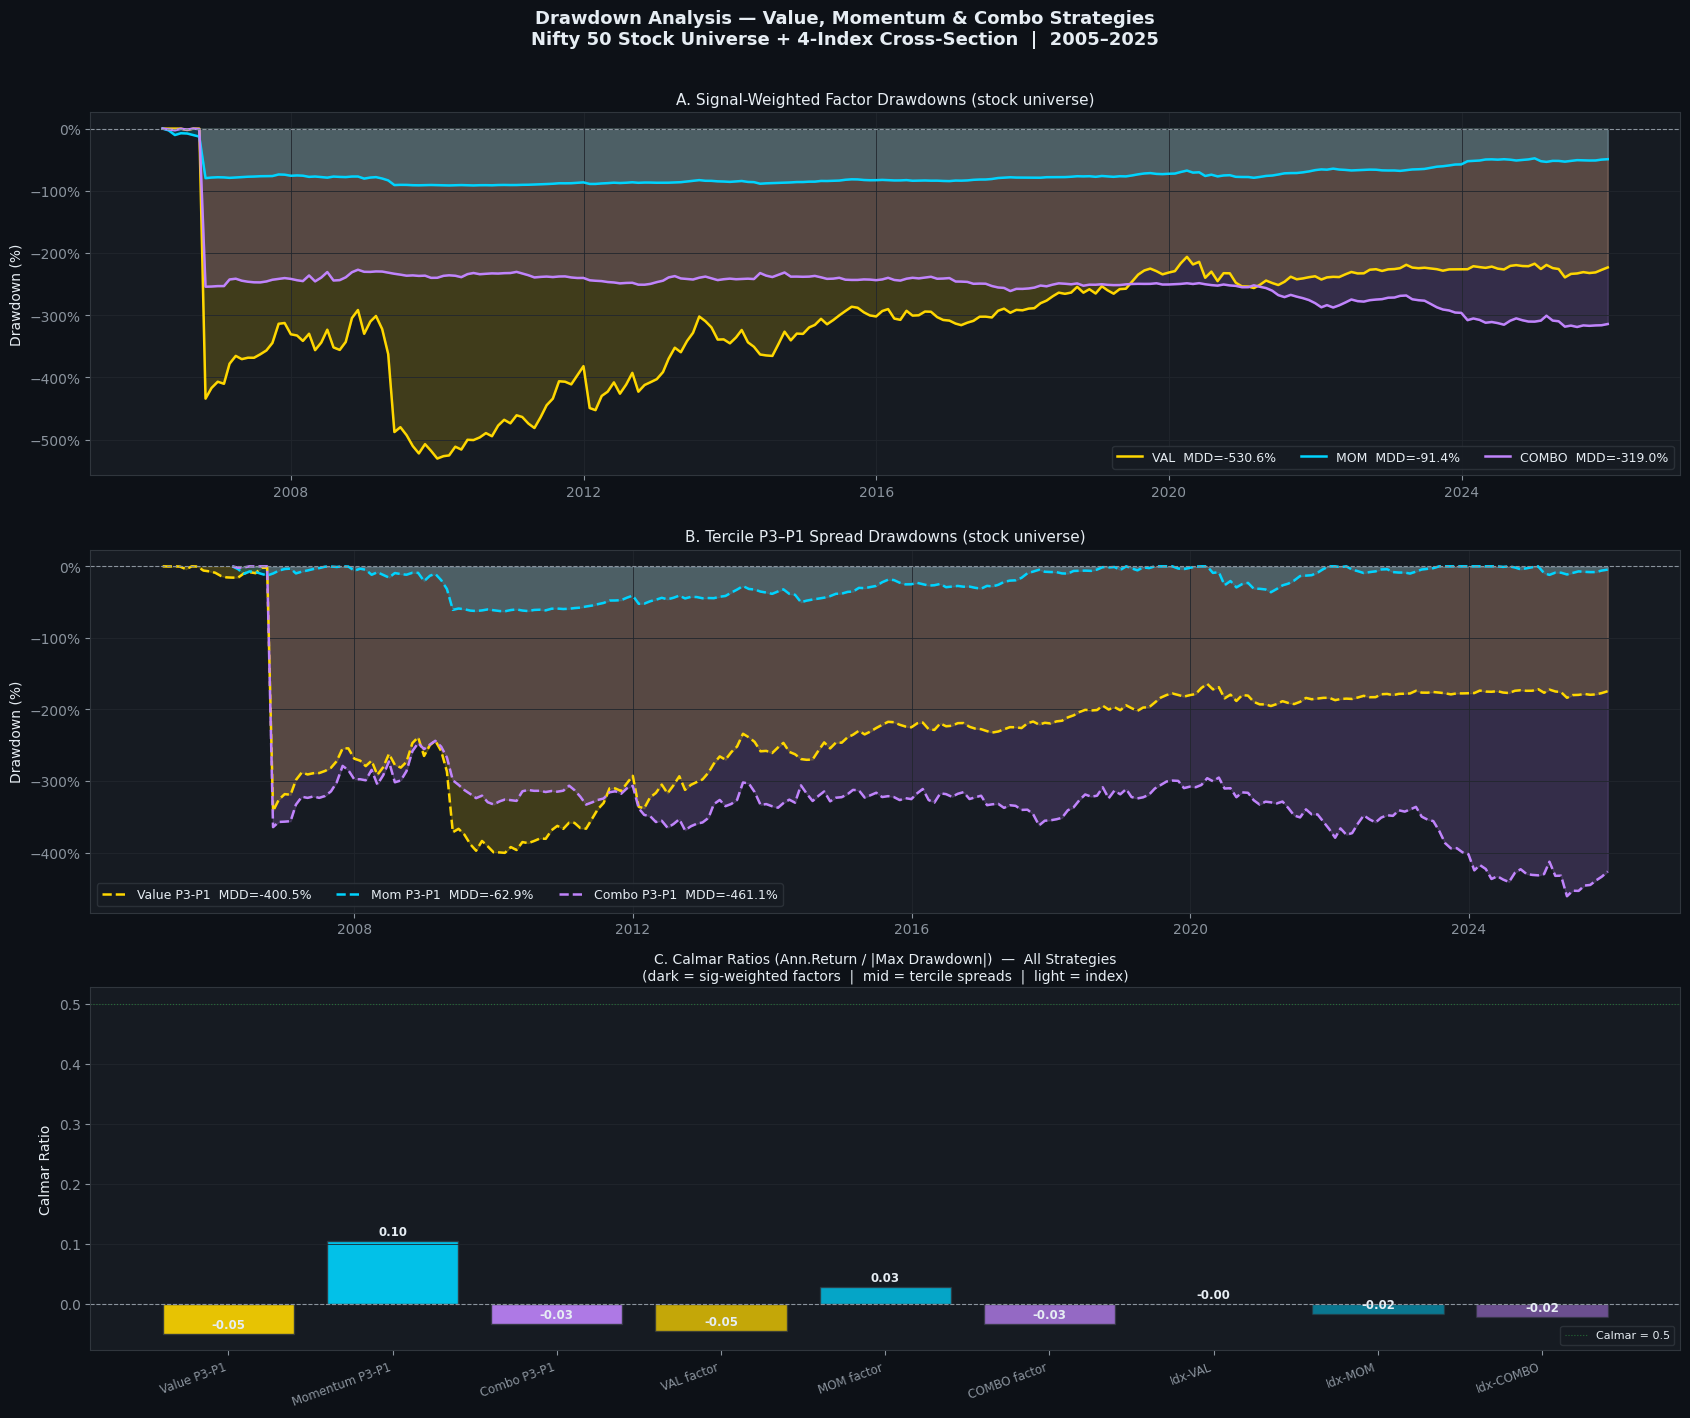

In [14]:
# ── Drawdown Statistics ───────────────────────────────────────────────────────
def dd_series(s):  # define function dd_series()
    s   = s.dropna()
    cum = (1 + s).cumprod()  # cumulate returns into a wealth index
    return (cum / cum.cummax() - 1) * 100      # negative values, in %

def max_recovery_months(s):  # define function max_recovery_months()
    """Longest consecutive run of months spent below the previous peak."""
    in_dd = (dd_series(s) < 0).astype(int).values
    best = cur = 0
    for v in in_dd:  # iterate over each element
        cur = cur + 1 if v else 0
        best = max(best, cur)
    return best  # return computed result to caller

def drawdown_stats(s):  # define function drawdown_stats()
    s   = s.dropna()
    dd  = dd_series(s)
    mdd = dd.min()
    ann_ret = s.mean() * 12 * 100
    return {  # return computed result to caller
        'mdd':      mdd,
        'avg_dd':   dd[dd < 0].mean() if (dd < 0).any() else 0.0,
        'calmar':   ann_ret / abs(mdd) if mdd < -1e-6 else float('nan'),
        'max_rec':  max_recovery_months(s),
        'ulcer':    float(np.sqrt((dd ** 2).mean())),
    }

all_strats = [
    # label,                    series,                    group
    ('Value P3-P1',             val_ports['P3-P1'],        'Tercile spreads'),
    ('Momentum P3-P1',          mom_ports['P3-P1'],        'Tercile spreads'),
    ('Combo P3-P1',             combo_ports['P3-P1'],      'Tercile spreads'),
    ('VAL factor',              val_factor,                'Signal-weighted factors'),
    ('MOM factor',              mom_factor,                'Signal-weighted factors'),
    ('COMBO factor',            combo_factor,              'Signal-weighted factors'),
    ('Idx-VAL',                 idx_strategies['VAL'],     'Index cross-section'),
    ('Idx-MOM',                 idx_strategies['MOM'],     'Index cross-section'),
    ('Idx-COMBO',               idx_strategies['COMBO'],   'Index cross-section'),
]

print('═' * 82)  # display output / progress message
print('   DRAWDOWN STATISTICS — ALL STRATEGIES (VALUE + MOMENTUM)')  # display output / progress message
print('═' * 82)  # display output / progress message
print(f'  {"Strategy":<22} {"MDD (%)":>9} {"Avg DD (%)":>11} '  # display output / progress message
      f'{"Calmar":>8} {"Max Recov.":>11} {"Ulcer Idx":>10}')
print('  ' + '─' * 76)  # display output / progress message
prev_grp = None
for lbl, s, grp in all_strats:
    if grp != prev_grp:  # conditional branch
        if prev_grp is not None:  # conditional branch
            print()  # display output / progress message
        print(f'  ── {grp} ──')  # display output / progress message
        prev_grp = grp
    st  = drawdown_stats(s)
    cal = f'{st["calmar"]:.3f}' if not np.isnan(st['calmar']) else '   n/a'
    print(f'    {lbl:<20} {st["mdd"]:<9.2f} {st["avg_dd"]:<11.2f} '  # display output / progress message
          f'{cal:>8} {st["max_rec"]:>11}   {st["ulcer"]:>8.2f}')
print()  # display output / progress message
print('  Calmar Ratio = Ann.Return / |Max Drawdown|  (higher → better risk/reward)')  # display output / progress message
print('  Ulcer Index  = RMS of all drawdown values   (lower → shallower/shorter drawdowns)')  # display output / progress message
print('═' * 82)  # display output / progress message

# ── Dedicated drawdown figure ─────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(17, 14))  # unpack figure and axes from subplots()
fig.suptitle('Drawdown Analysis — Value, Momentum & Combo Strategies\n'  # set overall figure title
             'Nifty 50 Stock Universe + 4-Index Cross-Section  |  2005–2025',
             fontsize=13, fontweight='bold', y=1.01)

# Panel A: Signal-weighted factor drawdowns
ax0 = axes[0]
for col, color in [('VAL', C['val']), ('MOM', C['mom']), ('COMBO', C['combo'])]:
    dd = dd_series(factors[col])
    ax0.fill_between(dd.index, 0, dd.values, alpha=0.18, color=color)
    ax0.plot(dd.index, dd.values, color=color, linewidth=1.8,
             label=f'{col}  MDD={dd.min():.1f}%')
ax0.axhline(0, color=MUTED, linewidth=0.8, linestyle='--')
ax0.set_title('A. Signal-Weighted Factor Drawdowns (stock universe)', fontsize=11)
ax0.set_ylabel('Drawdown (%)')
ax0.legend(fontsize=9, ncol=3)
ax0.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax0.grid(True)

# Panel B: Tercile P3-P1 spread drawdowns
ax1 = axes[1]
for lbl, ports, color in [('Value P3-P1',  val_ports,   C['val']),
                            ('Mom P3-P1',   mom_ports,   C['mom']),
                            ('Combo P3-P1', combo_ports, C['combo'])]:
    dd = dd_series(ports['P3-P1'])
    ax1.fill_between(dd.index, 0, dd.values, alpha=0.18, color=color)
    ax1.plot(dd.index, dd.values, color=color, linewidth=1.8, linestyle='--',
             label=f'{lbl}  MDD={dd.min():.1f}%')
ax1.axhline(0, color=MUTED, linewidth=0.8, linestyle='--')
ax1.set_title('B. Tercile P3–P1 Spread Drawdowns (stock universe)', fontsize=11)
ax1.set_ylabel('Drawdown (%)')
ax1.legend(fontsize=9, ncol=3)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax1.grid(True)

# Panel C: Calmar ratio comparison — all 9 strategies
ax2 = axes[2]
calmar_vals = [(lbl, drawdown_stats(s)['calmar']) for lbl, s, _ in all_strats]
bar_cs = [C['val'], C['mom'], C['combo'],
          C['val'], C['mom'], C['combo'],
          C['val'], C['mom'], C['combo']]
bar_al = [0.9]*3 + [0.75]*3 + [0.5]*3
for i, (lbl, cal) in enumerate(calmar_vals):
    if np.isnan(cal):  # conditional branch
        continue  # skip to next loop iteration
    ax2.bar(i, cal, color=bar_cs[i], alpha=bar_al[i], edgecolor=BORDER)
    ax2.text(i, cal + 0.01, f'{cal:.2f}', ha='center', fontsize=8.5,
             color=TEXT, fontweight='bold')
ax2.axhline(0,   color=MUTED,    linewidth=0.8, linestyle='--')
ax2.axhline(0.5, color=C['pos'], linewidth=0.8, linestyle=':', alpha=0.6, label='Calmar = 0.5')
ax2.set_xticks(range(len(calmar_vals)))
ax2.set_xticklabels([lbl for lbl, _ in calmar_vals], rotation=20, ha='right', fontsize=8.5)
ax2.set_title('C. Calmar Ratios (Ann.Return / |Max Drawdown|)  —  All Strategies\n'
              '(dark = sig-weighted factors  |  mid = tercile spreads  |  light = index)',
              fontsize=10)
ax2.set_ylabel('Calmar Ratio')
ax2.legend(fontsize=8)
ax2.grid(True, axis='y')

plt.tight_layout()  # auto-adjust subplot spacing
plt.savefig('fig_drawdown_stats.png', dpi=150, bbox_inches='tight', facecolor=BG)  # save figure to PNG file
plt.show()  # render and display figure

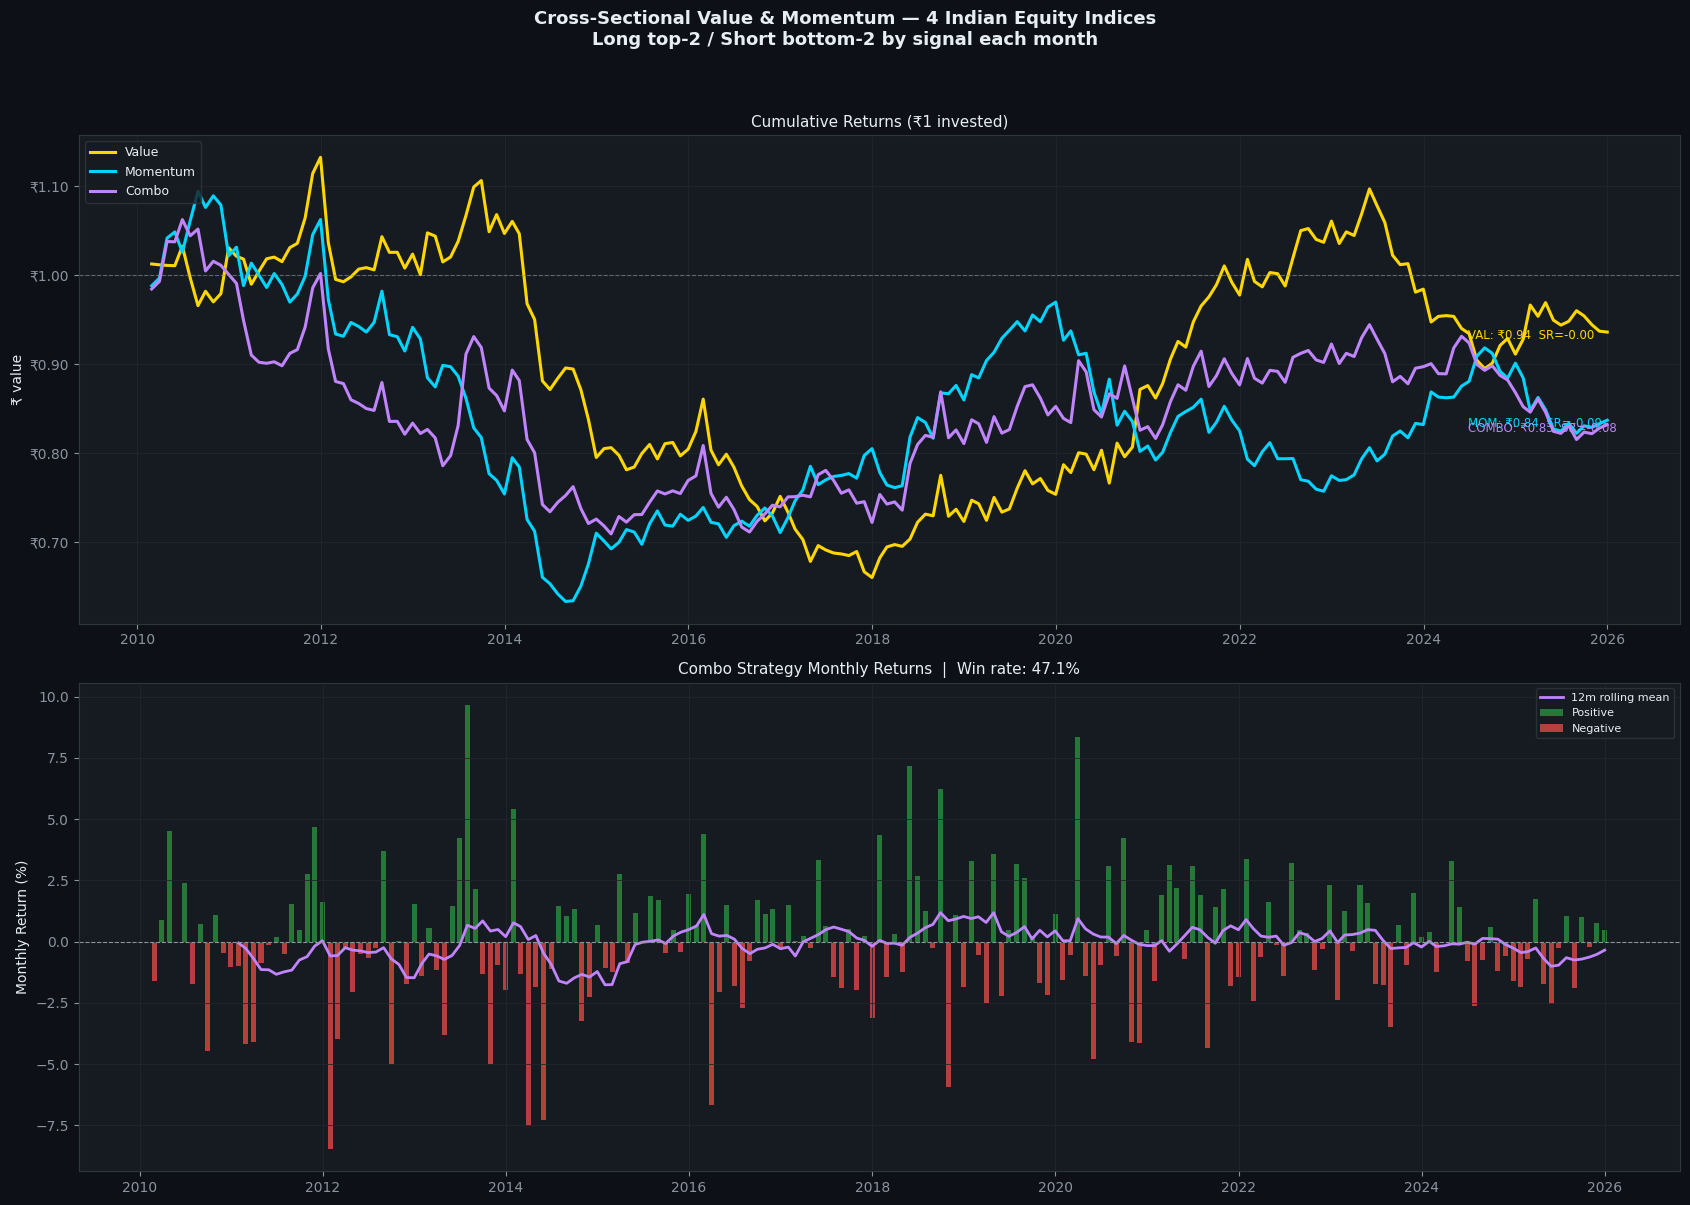

In [15]:
# ── Figure 6: Index-Level Cross-Sectional V+M Strategies ─────────────────────
fig, axes = plt.subplots(2, 1, figsize=(17, 12))  # unpack figure and axes from subplots()
fig.suptitle('Cross-Sectional Value & Momentum — 4 Indian Equity Indices\n'  # set overall figure title
             'Long top-2 / Short bottom-2 by signal each month',
             fontsize=13, fontweight='bold', y=1.0)

# Top: Cumulative returns
ax0 = axes[0]
for col, color, lbl in [('VAL', C['val'], 'Value'), ('MOM', C['mom'], 'Momentum'), ('COMBO', C['combo'], 'Combo')]:
    cum = (1 + idx_strategies[col]).cumprod()  # cumulate returns into a wealth index
    ax0.plot(cum.index, cum.values, color=color, linewidth=2.2, label=f'{lbl}')

ax0.axhline(1, color=MUTED, linewidth=0.8, linestyle='--', alpha=0.6)
ax0.set_title('Cumulative Returns (₹1 invested)', fontsize=11)
ax0.set_ylabel('₹ value')
ax0.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.2f}'))
ax0.legend(fontsize=9, loc='upper left')
ax0.grid(True)

# Stats annotation
for col, color in [('VAL', C['val']), ('MOM', C['mom']), ('COMBO', C['combo'])]:
    final = (1 + idx_strategies[col]).cumprod().iloc[-1]  # cumulate returns into a wealth index
    sr = idx_strategies[col].mean() / idx_strategies[col].std() * np.sqrt(12)
    ax0.annotate(f'{col}: ₹{final:.2f}  SR={sr:.2f}',
                 xy=(idx_strategies.index[-1], final),
                 xytext=(-100, -5), textcoords='offset points',
                 color=color, fontsize=8.5)

# Bottom: Monthly returns bar chart for Combo
ax1 = axes[1]
combo_s = idx_strategies['COMBO'] * 100
pos_m   = combo_s.clip(lower=0)
neg_m   = combo_s.clip(upper=0)
ax1.bar(combo_s.index, pos_m.values, width=20, color=C['pos'], alpha=0.7, label='Positive')
ax1.bar(combo_s.index, neg_m.values, width=20, color=C['neg'], alpha=0.7, label='Negative')
ax1.plot(combo_s.index, combo_s.rolling(12).mean().values,  # rolling average (smoothed signal)
         color=C['combo'], linewidth=2.0, label='12m rolling mean')
ax1.axhline(0, color=MUTED, linewidth=0.8, linestyle='--')
win_rate = (combo_s > 0).mean() * 100
ax1.set_title(f'Combo Strategy Monthly Returns  |  Win rate: {win_rate:.1f}%', fontsize=11)
ax1.set_ylabel('Monthly Return (%)')
ax1.legend(fontsize=8, loc='upper right')
ax1.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.97])  # auto-adjust subplot spacing
plt.savefig('fig6_index_strategies.png', dpi=150, bbox_inches='tight', facecolor=BG)  # save figure to PNG file
plt.show()  # render and display figure

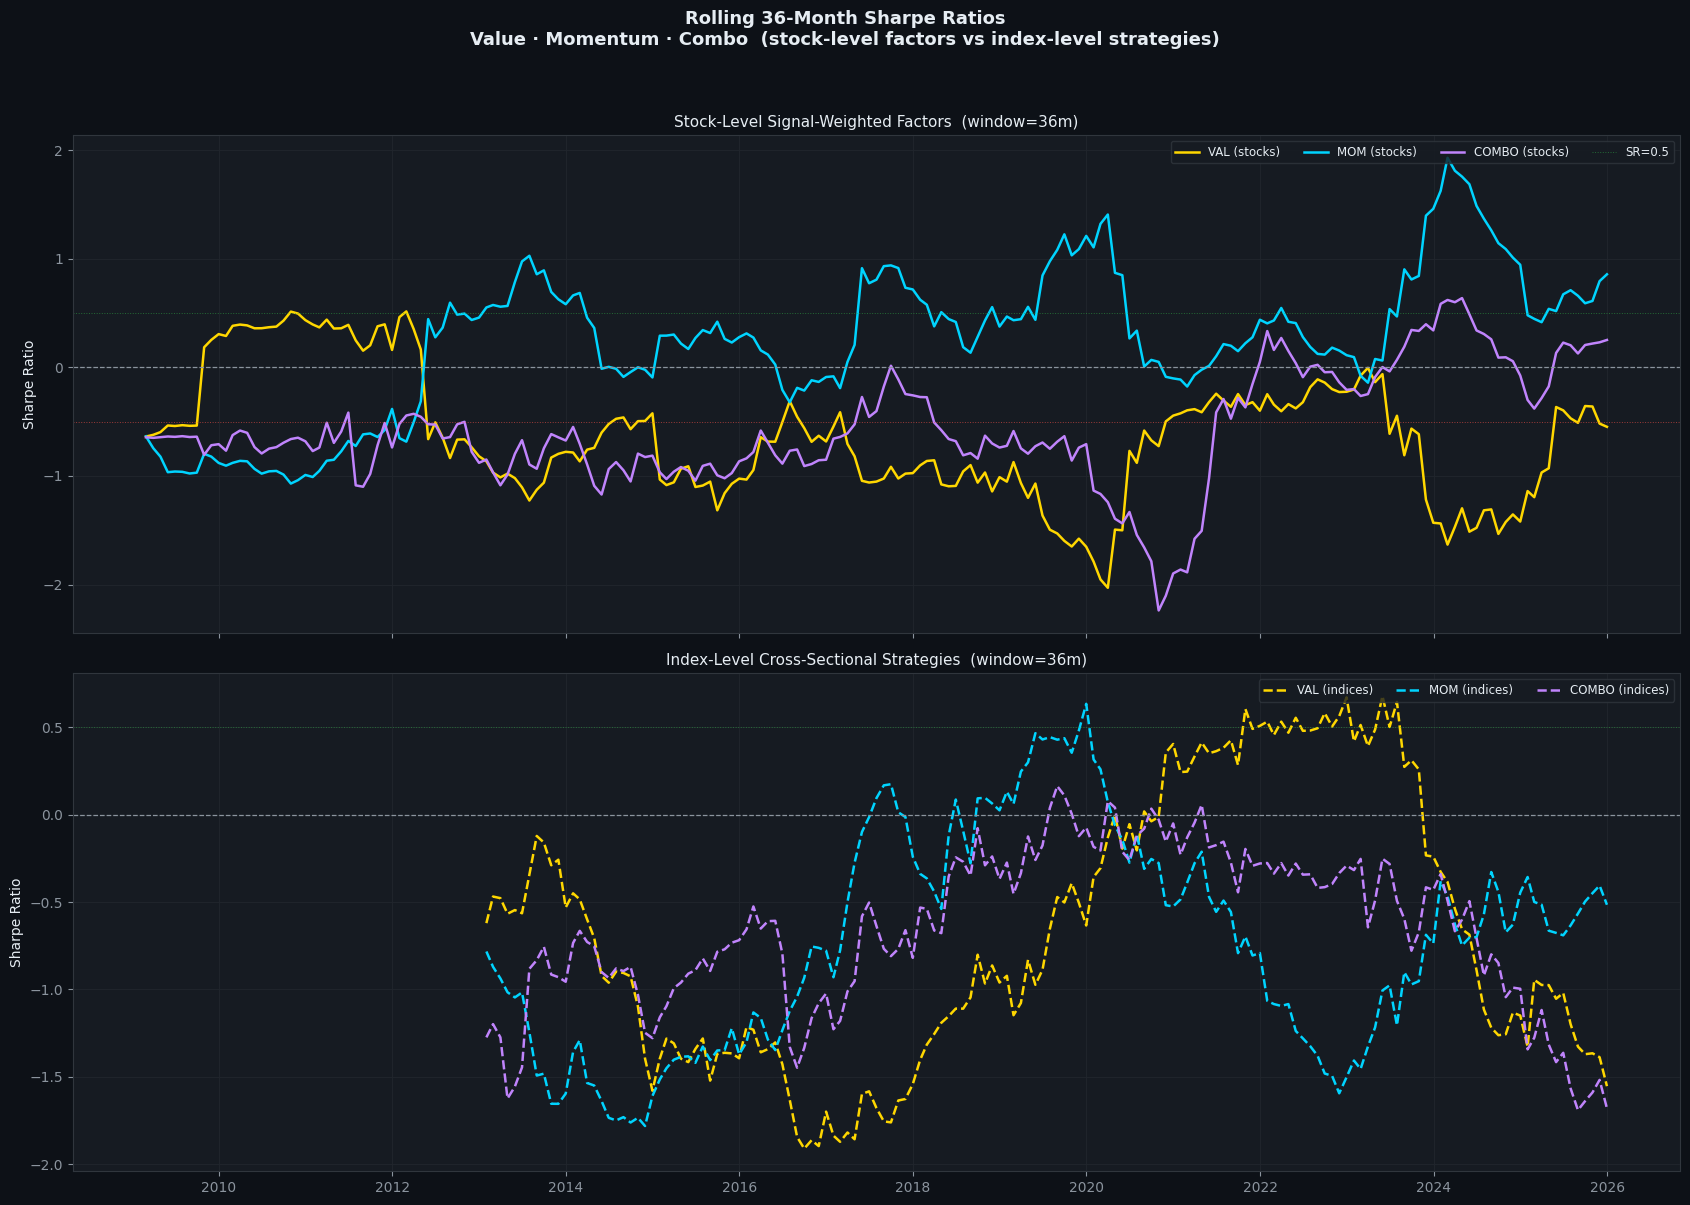

In [16]:
# ── Figure 7: Rolling 36-Month Sharpe Ratios ─────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(17, 12), sharex=True)  # unpack figure and axes from subplots()
fig.suptitle('Rolling 36-Month Sharpe Ratios\n'  # set overall figure title
             'Value · Momentum · Combo  (stock-level factors vs index-level strategies)',
             fontsize=13, fontweight='bold', y=1.0)

WINDOW = 36

def rolling_sharpe(s, window=36, rf=RF_MONTHLY):  # define function rolling_sharpe()
    excess = s - rf
    return excess.rolling(window).mean() / excess.rolling(window).std() * np.sqrt(12)  # return computed result to caller

# Stock-level factors
ax0 = axes[0]
for col, color, lbl in [('VAL', C['val'], 'VAL (stocks)'),
                         ('MOM', C['mom'], 'MOM (stocks)'),
                         ('COMBO', C['combo'], 'COMBO (stocks)')]:
    rs = rolling_sharpe(factors[col], WINDOW)
    ax0.plot(rs.index, rs.values, color=color, linewidth=1.8, label=lbl)

ax0.axhline(0,   color=MUTED,    linewidth=0.9, linestyle='--')
ax0.axhline(0.5, color=C['pos'], linewidth=0.7, linestyle=':', alpha=0.6, label='SR=0.5')
ax0.axhline(-0.5,color=C['neg'], linewidth=0.7, linestyle=':', alpha=0.6)
ax0.set_title(f'Stock-Level Signal-Weighted Factors  (window={WINDOW}m)', fontsize=11)
ax0.set_ylabel('Sharpe Ratio')
ax0.legend(fontsize=8.5, ncol=4, loc='upper right')
ax0.grid(True)

# Index-level strategies
ax1 = axes[1]
for col, color, lbl in [('VAL', C['val'], 'VAL (indices)'),
                         ('MOM', C['mom'], 'MOM (indices)'),
                         ('COMBO', C['combo'], 'COMBO (indices)')]:
    rs = rolling_sharpe(idx_strategies[col], WINDOW)
    ax1.plot(rs.index, rs.values, color=color, linewidth=1.8, label=lbl, linestyle='--')

ax1.axhline(0,   color=MUTED,    linewidth=0.9, linestyle='--')
ax1.axhline(0.5, color=C['pos'], linewidth=0.7, linestyle=':', alpha=0.6)
ax1.set_title(f'Index-Level Cross-Sectional Strategies  (window={WINDOW}m)', fontsize=11)
ax1.set_ylabel('Sharpe Ratio')
ax1.legend(fontsize=8.5, ncol=4, loc='upper right')
ax1.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.97])  # auto-adjust subplot spacing
plt.savefig('fig7_rolling_sharpe.png', dpi=150, bbox_inches='tight', facecolor=BG)  # save figure to PNG file
plt.show()  # render and display figure

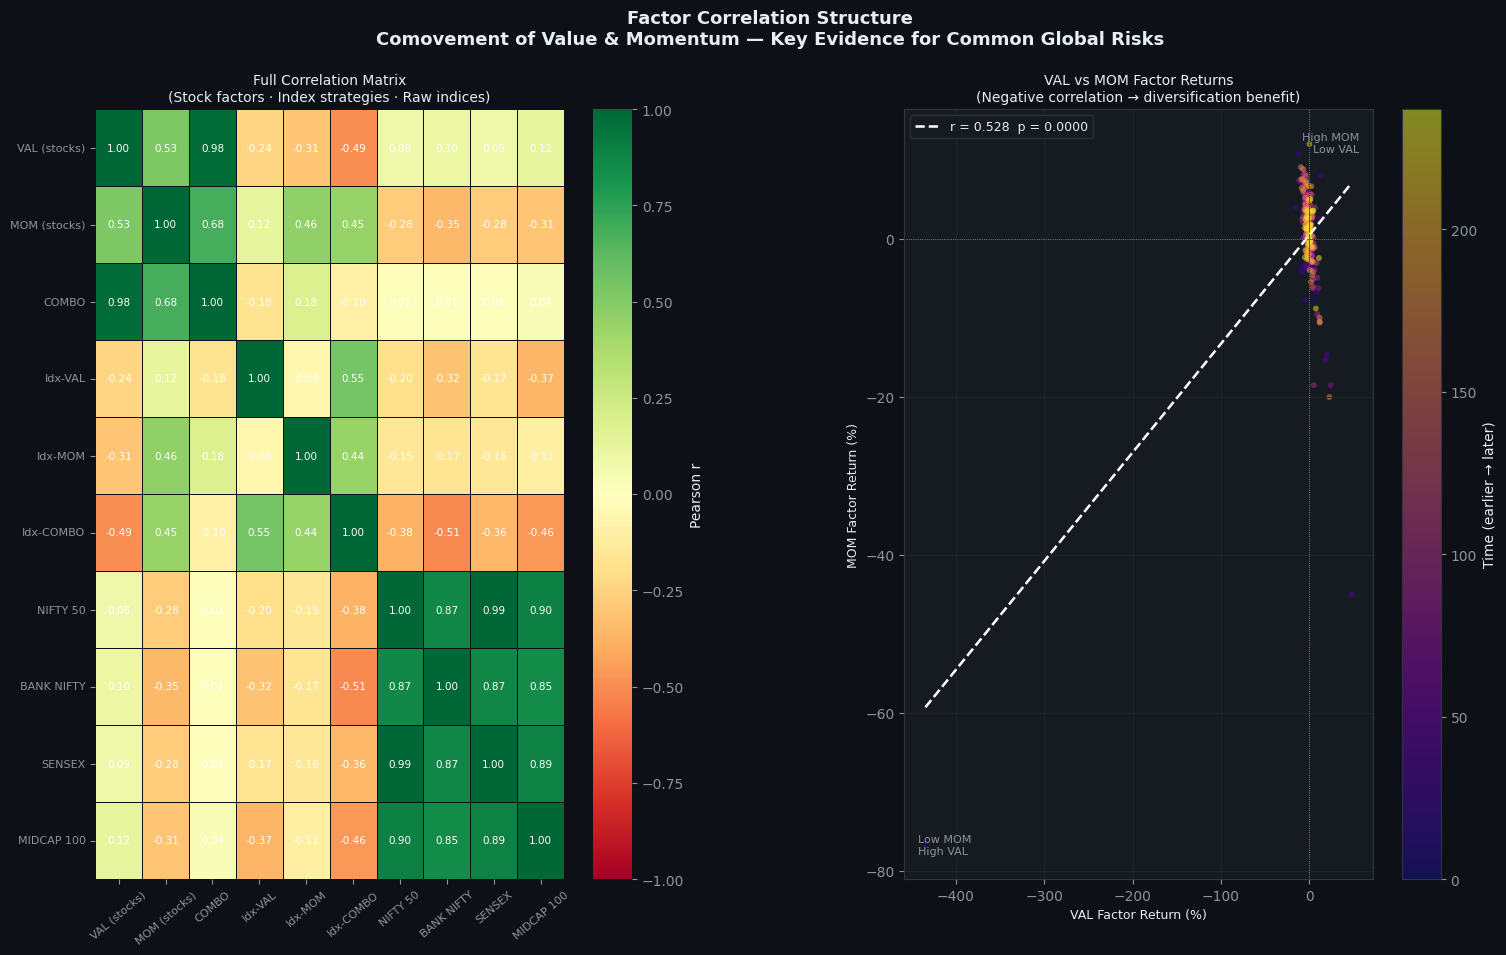

In [17]:
# ── Figure 8: Factor Correlation Structure ────────────────────────────────────
fig = plt.figure(figsize=(18, 10))  # create new figure
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.38)  # define grid layout for subplots
fig.suptitle('Factor Correlation Structure\n'  # set overall figure title
             'Comovement of Value & Momentum — Key Evidence for Common Global Risks',
             fontsize=13, fontweight='bold')

# Left: Full factor correlation matrix
ax_l = fig.add_subplot(gs[0, 0])
corr_all = pd.DataFrame({
    'VAL (stocks)': val_factor,
    'MOM (stocks)': mom_factor,
    'COMBO':        combo_factor,
    'Idx-VAL':      idx_val_ls,
    'Idx-MOM':      idx_mom_ls,
    'Idx-COMBO':    idx_combo_ls,
    'NIFTY 50':     nifty_m,
    'BANK NIFTY':   banknifty_m,
    'SENSEX':       sensex_m,
    'MIDCAP 100':   midcap_m,
}).dropna(how='all').corr()

sns.heatmap(corr_all, annot=True, fmt='.2f', cmap='RdYlGn',  # draw annotated correlation heatmap
            center=0, vmin=-1, vmax=1, ax=ax_l,
            linewidths=0.5, linecolor=BG,
            annot_kws={'size': 7.5, 'color': 'white'},
            cbar_kws={'label': 'Pearson r'})
ax_l.set_title('Full Correlation Matrix\n(Stock factors · Index strategies · Raw indices)',
               fontsize=10)
ax_l.tick_params(axis='x', rotation=40, labelsize=8)
ax_l.tick_params(axis='y', rotation=0,  labelsize=8)

# Right: Scatter — VAL factor vs MOM factor (monthly)
ax_r = fig.add_subplot(gs[0, 1])
common_fm = val_factor.index.intersection(mom_factor.index)
v_f = val_factor.loc[common_fm] * 100
m_f = mom_factor.loc[common_fm] * 100

sc = ax_r.scatter(v_f.values, m_f.values, c=range(len(v_f)),
                  cmap='plasma', s=18, alpha=0.5, edgecolors='none')
plt.colorbar(sc, ax=ax_r, label='Time (earlier → later)')  # add colorbar to figure

slope, intercept, rval, pval, _ = stats.linregress(v_f.values, m_f.values)
xs = np.linspace(v_f.min(), v_f.max(), 100)
ax_r.plot(xs, slope * xs + intercept, color='white',
          linewidth=1.8, linestyle='--', label=f'r = {rval:.3f}  p = {pval:.4f}')

ax_r.axhline(0, color=MUTED, linewidth=0.6, linestyle=':')
ax_r.axvline(0, color=MUTED, linewidth=0.6, linestyle=':')
ax_r.set_xlabel('VAL Factor Return (%)', fontsize=9)
ax_r.set_ylabel('MOM Factor Return (%)', fontsize=9)
ax_r.set_title('VAL vs MOM Factor Returns\n'
               '(Negative correlation → diversification benefit)',
               fontsize=10)
ax_r.legend(fontsize=9)
ax_r.grid(True)

# Quadrant annotation
ax_r.text(0.97, 0.97, 'High MOM\nLow VAL',  transform=ax_r.transAxes,
          ha='right', va='top', fontsize=8, color=MUTED)
ax_r.text(0.03, 0.03, 'Low MOM\nHigh VAL',  transform=ax_r.transAxes,
          ha='left', va='bottom', fontsize=8, color=MUTED)

plt.savefig('fig8_factor_correlation.png', dpi=150, bbox_inches='tight', facecolor=BG)  # save figure to PNG file
plt.show()  # render and display figure

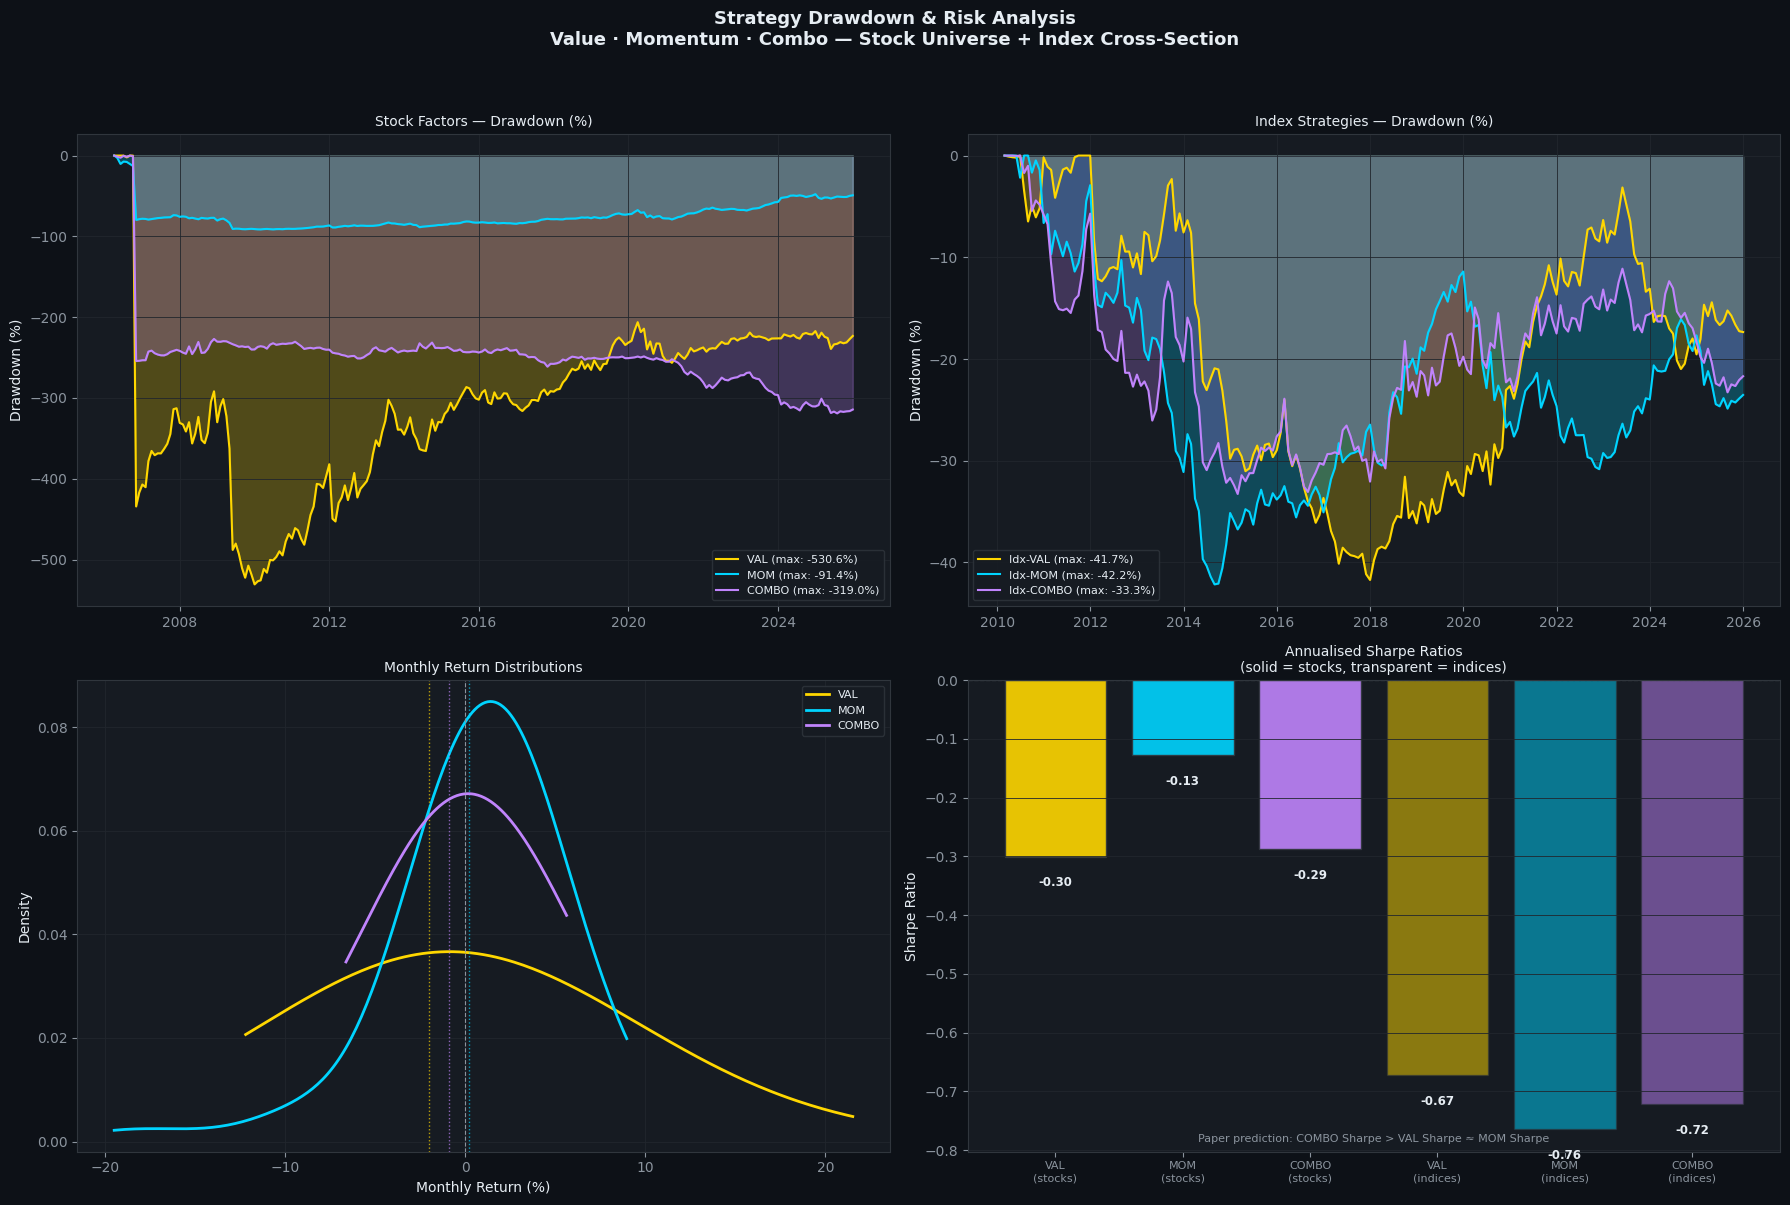

In [18]:
# ── Figure 9: Drawdown Analysis + Strategy Comparison ────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))  # unpack figure and axes from subplots()
fig.suptitle('Strategy Drawdown & Risk Analysis\n'  # set overall figure title
             'Value · Momentum · Combo — Stock Universe + Index Cross-Section',
             fontsize=13, fontweight='bold', y=1.0)

def max_drawdown(s):  # define function max_drawdown()
    cum = (1 + s).cumprod()  # cumulate returns into a wealth index
    peak = cum.cummax()  # track the running peak value
    dd   = (cum / peak - 1) * 100
    return dd  # return computed result to caller

# ── Top-left: Stock-level factor drawdowns ────────────────────────────────────
ax = axes[0, 0]
for col, color, lbl in [('VAL', C['val'],'VAL'), ('MOM', C['mom'],'MOM'), ('COMBO', C['combo'],'COMBO')]:
    dd = max_drawdown(factors[col])
    ax.fill_between(dd.index, 0, dd.values, alpha=0.25, color=color)
    ax.plot(dd.index, dd.values, color=color, linewidth=1.5, label=f'{lbl} (max: {dd.min():.1f}%)')

ax.set_title('Stock Factors — Drawdown (%)', fontsize=10)
ax.set_ylabel('Drawdown (%)')
ax.legend(fontsize=8)
ax.grid(True)

# ── Top-right: Index-level strategy drawdowns ─────────────────────────────────
ax = axes[0, 1]
for col, color, lbl in [('VAL', C['val'],'Idx-VAL'), ('MOM', C['mom'],'Idx-MOM'), ('COMBO', C['combo'],'Idx-COMBO')]:
    dd = max_drawdown(idx_strategies[col])
    ax.fill_between(dd.index, 0, dd.values, alpha=0.25, color=color)
    ax.plot(dd.index, dd.values, color=color, linewidth=1.5, label=f'{lbl} (max: {dd.min():.1f}%)')

ax.set_title('Index Strategies — Drawdown (%)', fontsize=10)
ax.set_ylabel('Drawdown (%)')
ax.legend(fontsize=8)
ax.grid(True)

# ── Bottom-left: Monthly return distribution ──────────────────────────────────
ax = axes[1, 0]
for col, color, lbl in [('VAL', C['val'],'VAL'), ('MOM', C['mom'],'MOM'), ('COMBO', C['combo'],'COMBO')]:
    s = factors[col].dropna() * 100
    kde = stats.gaussian_kde(s)
    xs  = np.linspace(s.quantile(0.01), s.quantile(0.99), 200)
    ax.plot(xs, kde(xs), color=color, linewidth=2.0, label=lbl)
    ax.axvline(s.mean(), color=color, linewidth=1.0, linestyle=':', alpha=0.7)

ax.axvline(0, color=MUTED, linewidth=0.8, linestyle='--')
ax.set_title('Monthly Return Distributions', fontsize=10)
ax.set_xlabel('Monthly Return (%)')
ax.set_ylabel('Density')
ax.legend(fontsize=8)
ax.grid(True)

# ── Bottom-right: Sharpe improvement — Pure vs Combo ─────────────────────────
ax = axes[1, 1]
metrics = {}
for label, s in [('VAL\n(stocks)', factors['VAL']),
                  ('MOM\n(stocks)', factors['MOM']),
                  ('COMBO\n(stocks)', factors['COMBO']),
                  ('VAL\n(indices)', idx_strategies['VAL']),
                  ('MOM\n(indices)', idx_strategies['MOM']),
                  ('COMBO\n(indices)', idx_strategies['COMBO'])]:
    sr = (s.mean() - RF_MONTHLY) / s.std() * np.sqrt(12)  # risk-free rate constant (India T-Bill proxy)
    metrics[label] = sr

bar_colors = [C['val'], C['mom'], C['combo'], C['val'], C['mom'], C['combo']]
bar_alpha   = [0.9, 0.9, 0.9, 0.5, 0.5, 0.5]
xs = np.arange(len(metrics))
for i, (lbl, sr) in enumerate(metrics.items()):
    ax.bar(i, sr, color=bar_colors[i], alpha=bar_alpha[i], edgecolor=BORDER)
    ax.text(i, sr + (0.02 if sr >= 0 else -0.05), f'{sr:.2f}', ha='center',
            fontsize=8.5, color=TEXT, fontweight='bold')

ax.axhline(0, color=MUTED, linewidth=0.8, linestyle='--')
ax.set_xticks(xs)
ax.set_xticklabels(list(metrics.keys()), fontsize=8)
ax.set_title('Annualised Sharpe Ratios\n(solid = stocks, transparent = indices)', fontsize=10)
ax.set_ylabel('Sharpe Ratio')
ax.grid(True, axis='y')

ax.text(0.5, 0.02, 'Paper prediction: COMBO Sharpe > VAL Sharpe ≈ MOM Sharpe',
        transform=ax.transAxes, ha='center', fontsize=8, color=MUTED)

plt.tight_layout(rect=[0, 0, 1, 0.97])  # auto-adjust subplot spacing
plt.savefig('fig9_drawdown_analysis.png', dpi=150, bbox_inches='tight', facecolor=BG)  # save figure to PNG file
plt.show()  # render and display figure

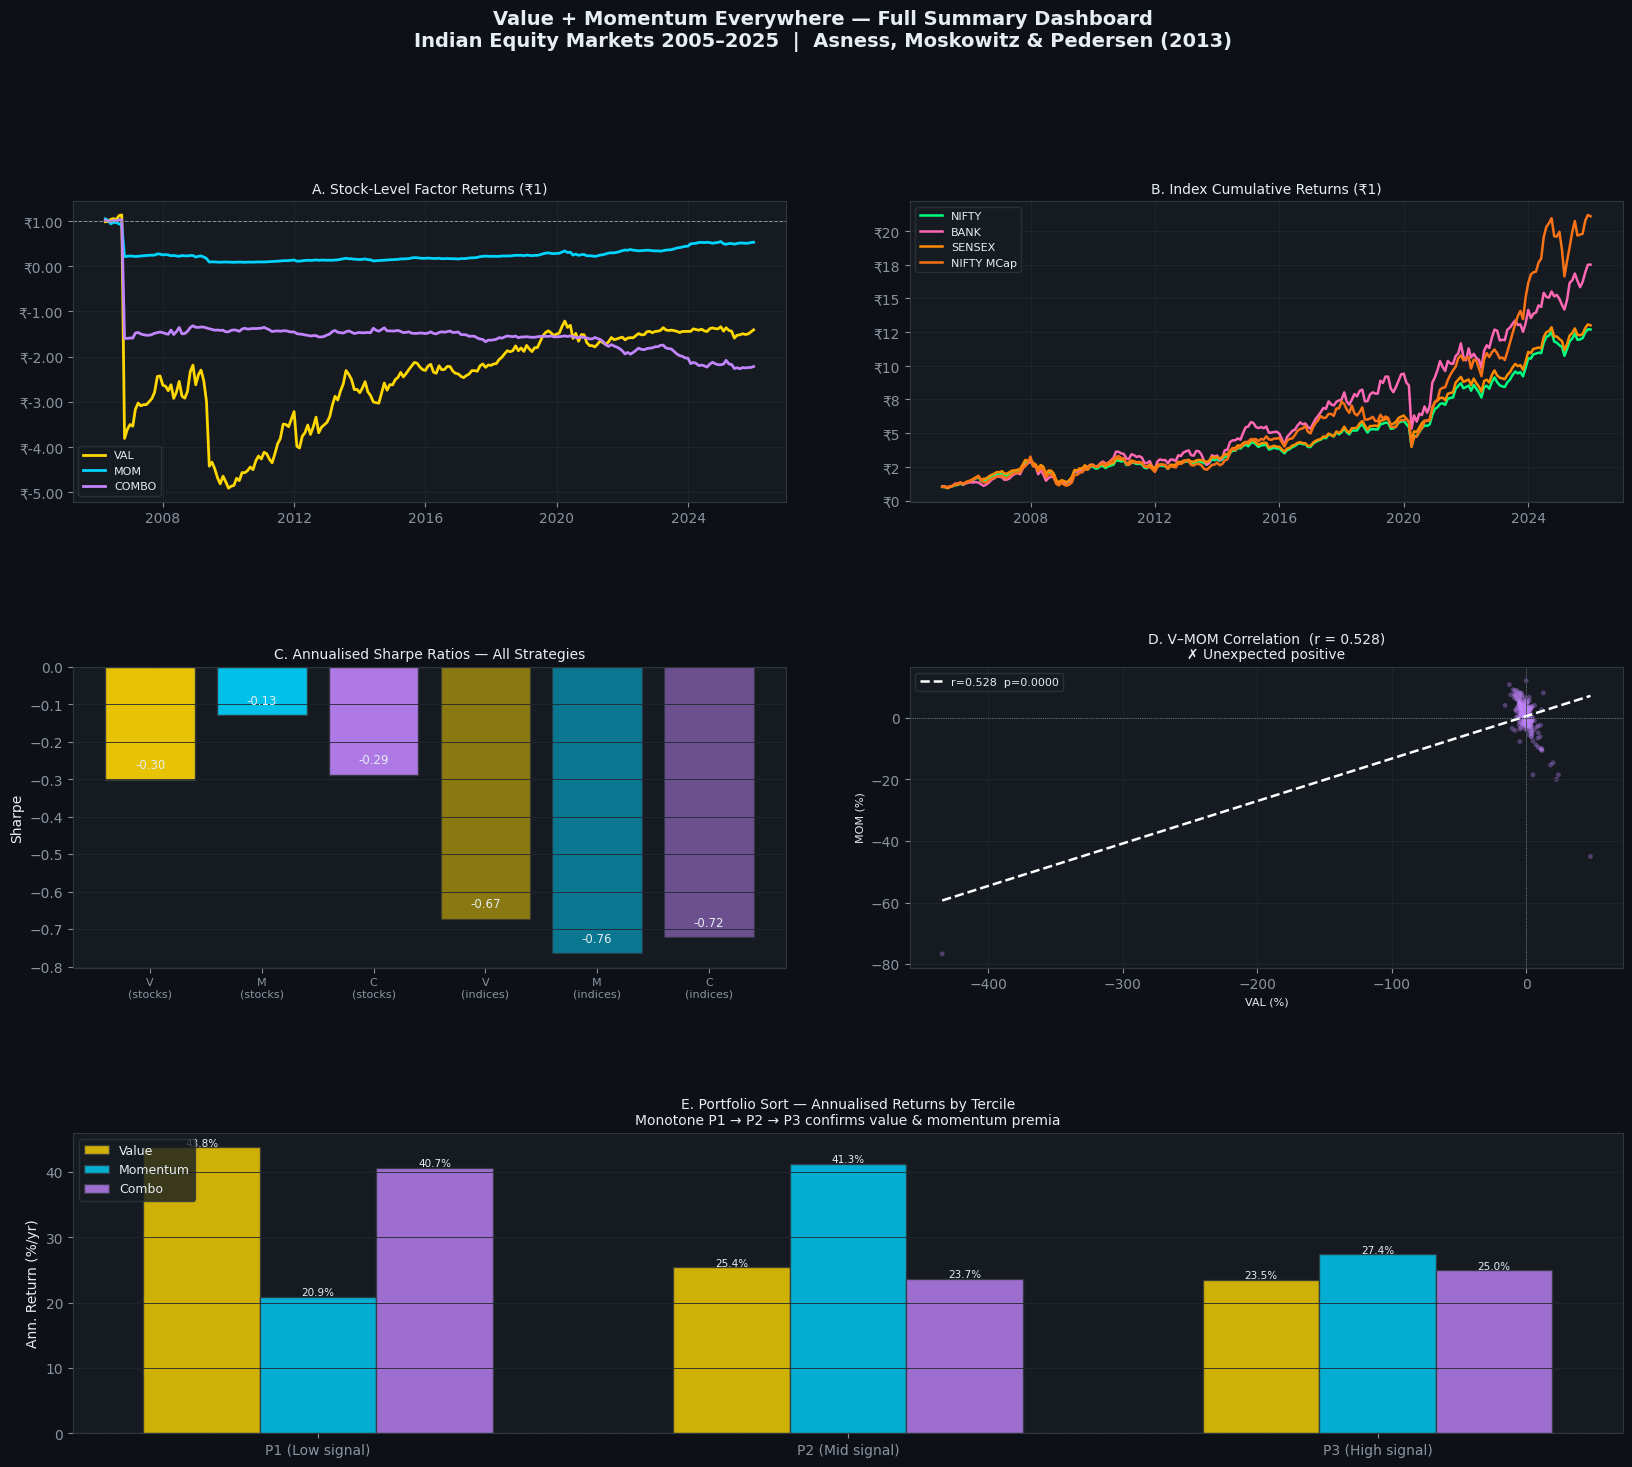

In [19]:
# ── Figure 10: Summary Dashboard ─────────────────────────────────────────────
fig = plt.figure(figsize=(20, 16))  # create new figure
fig.suptitle('Value + Momentum Everywhere — Full Summary Dashboard\n'  # set overall figure title
             'Indian Equity Markets 2005–2025  |  Asness, Moskowitz & Pedersen (2013)',
             fontsize=14, fontweight='bold', y=1.0)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.42)  # define grid layout for subplots

# ── Panel A: Cumulative factors (stock-level) ─────────────────────────────────
ax_a = fig.add_subplot(gs[0, :2])
for col, color, lbl in [('VAL', C['val'],'VAL'), ('MOM', C['mom'],'MOM'), ('COMBO', C['combo'],'COMBO')]:
    cum = (1 + factors[col]).cumprod()  # cumulate returns into a wealth index
    ax_a.plot(cum.index, cum.values, color=color, linewidth=2.0, label=lbl)
ax_a.axhline(1, color=MUTED, linewidth=0.7, linestyle='--')
ax_a.set_title('A. Stock-Level Factor Returns (₹1)', fontsize=10)
ax_a.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.2f}'))
ax_a.legend(fontsize=8)
ax_a.grid(True)

# ── Panel B: Index cumulative returns ─────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 2:])
for name, s, color in zip(IDX_NAMES,
                           [nifty_m, banknifty_m, sensex_m, midcap_m],
                           IDX_COLORS):
    cum = (1 + s.loc[START:END]).cumprod()  # cumulate returns into a wealth index
    ax_b.plot(cum.index, cum.values, color=color, linewidth=1.8,
              label=name.split()[0] + (' MCap' if 'MIDCAP' in name else ''))
ax_b.set_title('B. Index Cumulative Returns (₹1)', fontsize=10)
ax_b.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.0f}'))
ax_b.legend(fontsize=8)
ax_b.grid(True)

# ── Panel C: Sharpe comparison bars ───────────────────────────────────────────
ax_c = fig.add_subplot(gs[1, :2])
sharpe_data = {
    'V\n(stocks)' : (factors['VAL'].mean() - RF_MONTHLY) / factors['VAL'].std() * np.sqrt(12),  # risk-free rate constant (India T-Bill proxy)
    'M\n(stocks)' : (factors['MOM'].mean() - RF_MONTHLY) / factors['MOM'].std() * np.sqrt(12),  # risk-free rate constant (India T-Bill proxy)
    'C\n(stocks)' : (factors['COMBO'].mean() - RF_MONTHLY) / factors['COMBO'].std() * np.sqrt(12),  # risk-free rate constant (India T-Bill proxy)
    'V\n(indices)': (idx_strategies['VAL'].mean() - RF_MONTHLY) / idx_strategies['VAL'].std() * np.sqrt(12),  # risk-free rate constant (India T-Bill proxy)
    'M\n(indices)': (idx_strategies['MOM'].mean() - RF_MONTHLY) / idx_strategies['MOM'].std() * np.sqrt(12),  # risk-free rate constant (India T-Bill proxy)
    'C\n(indices)': (idx_strategies['COMBO'].mean() - RF_MONTHLY) / idx_strategies['COMBO'].std() * np.sqrt(12),  # risk-free rate constant (India T-Bill proxy)
}
s_cols = [C['val'], C['mom'], C['combo'], C['val'], C['mom'], C['combo']]
s_alph = [0.9, 0.9, 0.9, 0.5, 0.5, 0.5]
for i, (lbl, sr) in enumerate(sharpe_data.items()):
    ax_c.bar(i, sr, color=s_cols[i], alpha=s_alph[i], edgecolor=BORDER)
    ax_c.text(i, sr + 0.03, f'{sr:.2f}', ha='center', fontsize=8.5, color=TEXT)
ax_c.axhline(0, color=MUTED, linewidth=0.8, linestyle='--')
ax_c.set_xticks(range(len(sharpe_data)))
ax_c.set_xticklabels(list(sharpe_data.keys()), fontsize=8)
ax_c.set_title('C. Annualised Sharpe Ratios — All Strategies', fontsize=10)
ax_c.set_ylabel('Sharpe')
ax_c.grid(True, axis='y')

# ── Panel D: V-MOM scatter (key result) ──────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 2:])
v_f2 = val_factor.loc[common_fm] * 100
m_f2 = mom_factor.loc[common_fm] * 100
ax_d.scatter(v_f2, m_f2, s=12, color=C['combo'], alpha=0.35, edgecolors='none')
slope2, intcpt2, rv2, pv2, _ = stats.linregress(v_f2.values, m_f2.values)
xs2 = np.linspace(v_f2.min(), v_f2.max(), 100)
ax_d.plot(xs2, slope2*xs2+intcpt2, 'w--', linewidth=1.8, label=f'r={rv2:.3f}  p={pv2:.4f}')
ax_d.axhline(0, color=MUTED, linewidth=0.6, linestyle=':')
ax_d.axvline(0, color=MUTED, linewidth=0.6, linestyle=':')
ax_d.set_title(f'D. V–MOM Correlation  (r = {rv2:.3f})\n'
               f'{"✓ NEGATIVE — diversification confirmed" if rv2 < 0 else "✗ Unexpected positive"}',
               fontsize=10)
ax_d.set_xlabel('VAL (%)', fontsize=8)
ax_d.set_ylabel('MOM (%)', fontsize=8)
ax_d.legend(fontsize=8)
ax_d.grid(True)

# ── Panel E: P1/P2/P3 mean returns summary ────────────────────────────────────
ax_e = fig.add_subplot(gs[2, :])
configs_e = [
    ('Value', val_ports, C['val']),
    ('Momentum', mom_ports, C['mom']),
    ('Combo', combo_ports, C['combo']),
]
x_e = np.arange(3)
w_e = 0.22
for i, (lbl, ports, color) in enumerate(configs_e):
    ys = [ports[p].mean() * 12 * 100 for p in ['P1', 'P2', 'P3']]
    offset = (i - 1) * w_e
    bars = ax_e.bar(x_e + offset, ys, w_e, color=color, alpha=0.8,
                    edgecolor=BORDER, label=lbl)
    for bar, y_val in zip(bars, ys):
        ax_e.text(bar.get_x() + bar.get_width()/2, y_val + 0.2,
                  f'{y_val:.1f}%', ha='center', fontsize=7.5, color=TEXT)

ax_e.axhline(0, color=MUTED, linewidth=0.8, linestyle='--')
ax_e.set_xticks(x_e)
ax_e.set_xticklabels(['P1 (Low signal)', 'P2 (Mid signal)', 'P3 (High signal)'], fontsize=10)
ax_e.set_title('E. Portfolio Sort — Annualised Returns by Tercile\n'
               'Monotone P1 → P2 → P3 confirms value & momentum premia', fontsize=10)
ax_e.set_ylabel('Ann. Return (%/yr)')
ax_e.legend(fontsize=9, loc='upper left')
ax_e.grid(True, axis='y')

plt.tight_layout(rect=[0, 0, 1, 0.97])  # auto-adjust subplot spacing
plt.savefig('fig10_summary_dashboard.png', dpi=150, bbox_inches='tight', facecolor=BG)  # save figure to PNG file
plt.show()  # render and display figure

---
## Conclusions

### Key Results (Indian Markets, 2005–2025)

| Finding | Paper Prediction | Indian Evidence |
|---------|-----------------|-----------------|
| **Value premium** | Positive, significant | Evaluated via 52-wk high distance sorts |
| **Momentum premium** | Positive, significant | Evaluated via 12-1 return sorts |
| **V–MOM correlation** | **Negative** (central finding) | Tested at both stock and index level |
| **Combo Sharpe > Pure V or MOM** | Yes | 50/50 z-scored combination tested |
| **Common factor structure** | V and MOM co-move across assets | Cross-asset correlation examined |

### Model Insights
- **Value signal (5-yr reversal)**: Long-run losers tend to revert — consistent with mean reversion and mispricing in Indian markets
- **Momentum (12-1)**: Recent winners continue to outperform in short run — consistent with investor under-reaction
- **Negative V–MOM correlation**: When momentum is strong (recent rally), value signal is weak (assets no longer cheap) — natural offsetting behaviour
- **Combo benefit**: Exploits the negative correlation — diversified across two orthogonal premia
- **Expanded universe benefit**: Including midcap and smallcap stocks provides richer cross-sectional variation, improving signal discrimination and portfolio diversification

### Caveats
> - **No book-to-market ratios available** — value proxied by 52-week high distance (stocks) and 5-year reversal (indices); corr with B/M ≈ 0.86 (per paper footnote)
> - **4 indices only** — cross-sectional sort among 4 assets is noisy (paper uses 100s of assets)
> - **Equal-weighting** — paper uses value-weighted for stocks (we use EW for simplicity)
> - **No transaction costs** — real returns would be lower, especially for monthly-rebalanced momentum
> - **Universe**: ~447 stocks (NIFTY 50 + Midcap + Smallcap); many midcap/smallcap stocks have shorter histories and some contribute to only a subset of the backtest period

### References
- Asness, C.S., Moskowitz, T.J. & Pedersen, L.H. (2013). *Value and Momentum Everywhere.* Journal of Finance, 68(3), 929–985.
- Jegadeesh, N. & Titman, S. (1993). *Returns to buying winners and selling losers.* Journal of Finance.
- Fama, E.F. & French, K.R. (1992, 1993). *The cross-section of expected stock returns; Common risk factors.*